<a href="https://colab.research.google.com/github/GFrankTI/dataset-grupo-5-Japon-/blob/main/Copia_de_tp_final_cdd_por_frank_y_rei_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Carga de datos y exploración inicial**

In [43]:
# 1. Importar las librerías básicas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para que los gráficos se vean bien
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 2. Cargar el dataset
df = pd.read_csv('https://raw.githubusercontent.com/GFrankTI/dataset-grupo-5-Japon-/refs/heads/main/listings.csv')

Averiguamos la cantidad de filas y columnas con df.shape

In [44]:
df.shape

(27945, 18)

El dataset "listings" contiene 27945 filas y 18 columnas

In [45]:
#Vemos las primeras 5 filas para observar los datos que contienen
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,197677,Oshiage Holiday Apartment,964081,Yoshimi & Marek,NaN,Sumida Ku,35.71707,139.82608,Entire home/apt,12600.0,3,190,2025-08-24,1.11,1,183,10,M130003350
1,776070,Kero-kero room 1F,801494,Kei,NaN,Kita Ku,35.73844,139.76917,Private room,10459.0,3,272,2025-05-21,1.74,1,76,14,M130000243
2,905944,4F Spacious Apartment in Shinjuku / Shibuya Tokyo,4847803,Best Stay In Tokyo!,NaN,Shibuya Ku,35.67878,139.67847,Entire home/apt,33671.0,5,281,2025-09-21,1.85,9,305,50,Hotels and Inns Business Act | 渋谷区保健所長 | 31渋健生...
3,1016831,5 mins Shibuya Cat modern sunny Shimokita,5596383,Wakana,NaN,Setagaya Ku,35.65800,139.67134,Private room,24143.0,1,284,2025-09-21,1.87,1,80,16,M130001107
4,1196177,Homestay at Host's House - Senju-Ohashi Station,5686404,Yukiko,NaN,Adachi Ku,35.74363,139.79852,Private room,8795.0,2,150,2025-09-07,1.01,1,253,25,M130007760


Visualizamos los nombres de las columnas y el tipo de dato que contienen con dtypes



In [46]:
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,float64
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,float64


In [47]:
# Ver un resumen general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27945 entries, 0 to 27944
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              27945 non-null  int64  
 1   name                            27945 non-null  object 
 2   host_id                         27945 non-null  int64  
 3   host_name                       27938 non-null  object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   27945 non-null  object 
 6   latitude                        27945 non-null  float64
 7   longitude                       27945 non-null  float64
 8   room_type                       27945 non-null  object 
 9   price                           25480 non-null  float64
 10  minimum_nights                  27945 non-null  int64  
 11  number_of_reviews               27945 non-null  int64  
 12  last_review                     

In [48]:
# Ver estadisticas rapidas
resumen=df.describe().round(2)
print(resumen)

                 id       host_id  neighbourhood_group  latitude  longitude  \
count  2.794500e+04  2.794500e+04                  0.0  27945.00   27945.00   
mean   9.498544e+17  3.789153e+08                  NaN     35.70     139.74   
std    5.379956e+17  2.177878e+08                  NaN      0.04       0.07   
min    1.976770e+05  3.222340e+05                  NaN     35.52     139.08   
25%    7.624382e+17  1.895020e+08                  NaN     35.69     139.70   
50%    1.169462e+18  4.254235e+08                  NaN     35.70     139.73   
75%    1.362098e+18  5.573665e+08                  NaN     35.72     139.79   
max    1.519526e+18  7.210764e+08                  NaN     35.84     139.91   

            price  minimum_nights  number_of_reviews  reviews_per_month  \
count    25480.00        27945.00           27945.00           24009.00   
mean     24781.88            5.32              35.97               1.68   
std      77865.75           10.72              66.33           

**Diccionario de Variables**

| Variable | Tipo | Descripción Técnica | Uso en Modelo | Notas de Limpieza/Transformación |
|-----------|--------|---------------------|---------------|----------------------------------|
| `id` | int64 | Identificador único del listing en Airbnb | ❌ Descartar | ID sin valor predictivo; usar solo para trazabilidad |
| `name` | object | Título del anuncio (texto libre) | ❌ Descartar | Texto no estructurado; requeriría NLP avanzado para extracción de features |
| `host_id` | int64 | Identificador único del anfitrión | ⚠️ Feature derivada | Usar para calcular `host_listings_count`; descartar como feature directa |
| `host_name` | object | Nombre público del anfitrión | ❌ Descartar | Texto libre sin valor predictivo directo |
| `neighbourhood_group` | float64 | Grupo macro de barrios (ej: "Tokyo Ward") | ❌ Descartar | 100% nulos en este dataset; no usable |
| `neighbourhood` | object | Nombre del barrio específico (ej: "Shinjuku Ku") | ✅ Feature categórica | Aplicar Target Encoding suavizado o One-Hot Encoding; 49 valores únicos |
| `latitude` | float64 | Coordenada geográfica norte-sur (WGS84) | ✅ Feature geográfica | Usar para calcular `distance_to_center`, `distance_to_stations`, densidad espacial |
| `longitude` | float64 | Coordenada geográfica este-oeste (WGS84) | ✅ Feature geográfica | Combinar con `latitude` para features espaciales; rango aproximado: 139.0 a 139.9 |
| `room_type` | object | Tipo de alojamiento: Entire home/apt, Private room, Shared room | ✅ Feature categórica | One-Hot Encoding (`drop_first=True`); variable clave para segmentación de precio |
| `price` | float64 | Precio por noche en JPY (limpio: sin `$` ni `,`) | 🎯 Variable objetivo | Transformar con `np.log1p()` para modelado; winsorizar P99.5 para outliers extremos |
| `minimum_nights` | int64 | Noches mínimas requeridas para reserva | ✅ Feature numérica | Variable de política del host; posible transformación log si presenta sesgo |
| `number_of_reviews` | int64 | Cantidad acumulada de reviews recibidas | ✅ Feature numérica | Crear `log_number_of_reviews` para compresión de escala; proxy de popularidad |
| `last_review` | object | Fecha de la última review recibida (YYYY-MM-DD) | ✅ Feature derivada | Convertir a datetime y calcular `days_since_last_review` |
| `reviews_per_month` | float64 | Promedio mensual de reviews calculado por Airbnb | ✅ Feature numérica | Imputar 0 para listings sin reviews; semánticamente correcto |
| `calculated_host_listings_count` | int64 | Cantidad total de listings activos del anfitrión | ✅ Feature numérica | Proxy de experiencia/profesionalismo del host; posible transformación log |
| `availability_365` | int64 | Días disponibles para reserva en los próximos 365 días | ✅ Feature numérica | Calcular `occupancy_rate_est = 1 - (availability_365 / 365)`; clip entre 0 y 1 |
| `number_of_reviews_ltm` | int64 | Reviews recibidas en los últimos 12 meses (Last Twelve Months) | ✅ Feature numérica | Proxy de demanda reciente; menos sensible a antigüedad que `number_of_reviews` |
| `license` | object | Código de licencia municipal bajo Minpaku Law | ⚠️ Feature opcional | Alta cardinalidad (~17k valores únicos); descartar o usar solo para validación legal |

    'neighbourhood', 'latitude', 'longitude', 'room_type', 'minimum_nights',
    'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
    'availability_365', 'demand_tier', 'popularity_index

### 1.2 Revisión General y Contexto de Negocio (Solo Dataset "Listings")

Antes de proceder a la limpieza, analizamos la naturaleza de las variables para entender el contexto real de Tokio:

1. **El Target (Variable a predecir):** La columna `price` representa el precio por noche. Notamos que viene limpia (numérica), pero tiene valores nulos que deberemos tratar.
2. **Geografía y División Administrativa (El caso de los Vecindarios):**
   - La columna `neighbourhood_group` está 100% vacía. En otras ciudades, esta columna agrupa los barrios por regiones grandes.
   - **Hallazgo clave:** En Tokio, esta información no viene dada, pero está *oculta* en la columna `neighbourhood`. Los barrios japoneses terminan con sufijos que indican su tipo de división administrativa:
     - **Ku (区):** Distritos Especiales (el centro urbano de Tokio, ej. *Shibuya Ku*).
     - **Shi (市):** Ciudades (zonas más exteriores o suburbanas, ej. *Hachioji Shi*).
     - **Mura (村) / Machi (町):** Villas y Pueblos (zonas rurales o islas remotas).
   - **Decisión:** En lugar de borrar `neighbourhood_group` por estar vacía, demostraremos que podemos extraer esta información desde `neighbourhood` si el modelo lo requiere, o simplemente usar el barrio específico (`neighbourhood`) que es incluso más detallado.
3. **Variables de Actividad:** Columnas como `reviews_per_month` o `last_review` tendrán nulos. No son errores de carga, sino que representan propiedades nuevas o inactivas.

# 2: Limpieza de datos

In [49]:
# =============================================================================
# PASO 2: LIMPIEZA DE DATOS
# =============================================================================

print("📊 ESTADO INICIAL:")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print(f"Nulos totales: {df.isnull().sum().sum()}")
print("\n" + "="*60)

# 1. ELIMINAR DUPLICADOS (si los hubiera)
df.drop_duplicates(inplace=True)
print("✅ Duplicados eliminados")

# 2. LIMPIAR PRECIOS NULOS (variable objetivo)
# Decisión: Eliminamos las filas sin precio porque es nuestra variable a predecir
filas_sin_precio = df['price'].isnull().sum()
df.dropna(subset=['price'], inplace=True)
print(f"✅ Filas sin precio eliminadas: {filas_sin_precio}")

# 3. RELLENAR HOST_NAME NULOS
df['host_name'] = df['host_name'].fillna('Desconocido') # Corregido para evitar FutureWarning
print("✅ Nulos en 'host_name' rellenados con 'Desconocido'")

# 4. RELLENAR REVIEWS_PER_MONTH CON 0
# (son propiedades sin reseñas, no es un error, es información válida)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0) # Corregido para evitar FutureWarning
print("✅ Nulos en 'reviews_per_month' rellenados con 0")

# 5. RELLENAR LICENSE CON "No Regulado"
df['license'] = df['license'].fillna('Sin licencia') # Corregido para evitar FutureWarning
print("✅ Nulos en 'license' rellenados con 'Sin licencia'")

# 6. LAST_REVIEW: Lo dejamos como está (NaT = sin reseñas)
# No lo tocamos porque es información temporal válida
print("ℹ️  'last_review' se mantiene con NaT (propiedades sin reseñas)")

print("\n" + "="*60)
print("📊 ESTADO FINAL POST-LIMPIEZA:")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print(f"Nulos restantes: {df.isnull().sum().sum()}")
print("\n📋 Resumen de nulos por columna:")
print(df.isnull().sum())

📊 ESTADO INICIAL:
Filas: 27945 | Columnas: 18
Nulos totales: 38305

✅ Duplicados eliminados
✅ Filas sin precio eliminadas: 2465
✅ Nulos en 'host_name' rellenados con 'Desconocido'
✅ Nulos en 'reviews_per_month' rellenados con 0
✅ Nulos en 'license' rellenados con 'Sin licencia'
ℹ️  'last_review' se mantiene con NaT (propiedades sin reseñas)

📊 ESTADO FINAL POST-LIMPIEZA:
Filas: 25480 | Columnas: 18
Nulos restantes: 28977

📋 Resumen de nulos por columna:
id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group               25480
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                        3497
reviews_per_month     

In [50]:
display(df.head())

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,197677,Oshiage Holiday Apartment,964081,Yoshimi & Marek,NaN,Sumida Ku,35.71707,139.82608,Entire home/apt,12600.0,3,190,2025-08-24,1.11,1,183,10,M130003350
1,776070,Kero-kero room 1F,801494,Kei,NaN,Kita Ku,35.73844,139.76917,Private room,10459.0,3,272,2025-05-21,1.74,1,76,14,M130000243
2,905944,4F Spacious Apartment in Shinjuku / Shibuya Tokyo,4847803,Best Stay In Tokyo!,NaN,Shibuya Ku,35.67878,139.67847,Entire home/apt,33671.0,5,281,2025-09-21,1.85,9,305,50,Hotels and Inns Business Act | 渋谷区保健所長 | 31渋健生...
3,1016831,5 mins Shibuya Cat modern sunny Shimokita,5596383,Wakana,NaN,Setagaya Ku,35.65800,139.67134,Private room,24143.0,1,284,2025-09-21,1.87,1,80,16,M130001107
4,1196177,Homestay at Host's House - Senju-Ohashi Station,5686404,Yukiko,NaN,Adachi Ku,35.74363,139.79852,Private room,8795.0,2,150,2025-09-07,1.01,1,253,25,M130007760


In [51]:
# Para confirmar que 'neighbourhood' contiene los nombres de los barrios (sin sufijos)
print("📊 Distribución de los 10 barrios más frecuentes en la columna 'neighbourhood':")
display(df['neighbourhood'].value_counts().head(10))

📊 Distribución de los 10 barrios más frecuentes en la columna 'neighbourhood':


,count
neighbourhood,
Shinjuku Ku,4559
Sumida Ku,3610
Taito Ku,2613
Toshima Ku,2458
Shibuya Ku,1756
Minato Ku,1094
Ota Ku,1066
Setagaya Ku,881
Katsushika Ku,857


Extraemos la última palabra de cada barrio para ver los sufijos japoneses. Esto prueba que 'neighbourhood_group' está vacía porque la info ya está en 'neighbourhood'

In [52]:
# 1. Extraemos el sufijo (la última palabra) de neighbourhood para añadirla a neighbourhood_group
df['neighbourhood_group'] = df['neighbourhood'].apply(lambda x: x.split()[-1])

# 2. Le quitamos el sufijo al nombre original del barrio (nos quedamos con todo menos la última palabra)
df['neighbourhood'] = df['neighbourhood'].apply(lambda x: " ".join(x.split()[:1]))

# Veamos cómo queda:
display(df.head())

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,197677,Oshiage Holiday Apartment,964081,Yoshimi & Marek,Ku,Sumida,35.71707,139.82608,Entire home/apt,12600.0,3,190,2025-08-24,1.11,1,183,10,M130003350
1,776070,Kero-kero room 1F,801494,Kei,Ku,Kita,35.73844,139.76917,Private room,10459.0,3,272,2025-05-21,1.74,1,76,14,M130000243
2,905944,4F Spacious Apartment in Shinjuku / Shibuya Tokyo,4847803,Best Stay In Tokyo!,Ku,Shibuya,35.67878,139.67847,Entire home/apt,33671.0,5,281,2025-09-21,1.85,9,305,50,Hotels and Inns Business Act | 渋谷区保健所長 | 31渋健生...
3,1016831,5 mins Shibuya Cat modern sunny Shimokita,5596383,Wakana,Ku,Setagaya,35.65800,139.67134,Private room,24143.0,1,284,2025-09-21,1.87,1,80,16,M130001107
4,1196177,Homestay at Host's House - Senju-Ohashi Station,5686404,Yukiko,Ku,Adachi,35.74363,139.79852,Private room,8795.0,2,150,2025-09-07,1.01,1,253,25,M130007760


cargamos los nombres de el tipo de vecindario en español

In [53]:
diccionario_tokio = {
    'Ku': 'Distrito Especial',
    'Shi': 'Ciudad',
    'Mura': 'Villa',
    'Machi': 'Pueblo'
}

df['neighbourhood_group'] = (
    df['neighbourhood_group']
    .replace(diccionario_tokio)
)

df.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,197677,Oshiage Holiday Apartment,964081,Yoshimi & Marek,Distrito Especial,Sumida,35.71707,139.82608,Entire home/apt,12600.0,3,190,2025-08-24,1.11,1,183,10,M130003350
1,776070,Kero-kero room 1F,801494,Kei,Distrito Especial,Kita,35.73844,139.76917,Private room,10459.0,3,272,2025-05-21,1.74,1,76,14,M130000243
2,905944,4F Spacious Apartment in Shinjuku / Shibuya Tokyo,4847803,Best Stay In Tokyo!,Distrito Especial,Shibuya,35.67878,139.67847,Entire home/apt,33671.0,5,281,2025-09-21,1.85,9,305,50,Hotels and Inns Business Act | 渋谷区保健所長 | 31渋健生...
3,1016831,5 mins Shibuya Cat modern sunny Shimokita,5596383,Wakana,Distrito Especial,Setagaya,35.65800,139.67134,Private room,24143.0,1,284,2025-09-21,1.87,1,80,16,M130001107
4,1196177,Homestay at Host's House - Senju-Ohashi Station,5686404,Yukiko,Distrito Especial,Adachi,35.74363,139.79852,Private room,8795.0,2,150,2025-09-07,1.01,1,253,25,M130007760


In [54]:
# Contamos cuántos barrios hay de cada tipo
print("\n📊 Distribución de tipos de vecindarios:")
display(df['neighbourhood_group'].value_counts())


📊 Distribución de tipos de vecindarios:


,count
neighbourhood_group,
Distrito Especial,24962
Ciudad,509
Pueblo,5
Villa,4


Detectamos que las categorías 'Villa' y 'Pueblo' representaban menos del 1% del dataset y correspondían a zonas rurales o islas remotas de Tokio (como Aogashima). Estas no son destinos turísticos típicos para extranjeros, que es nuestro caso de uso. Además, al tener tan pocos datos, generaban outliers que distorsionaban las visualizaciones y el modelo. Decidimos enfocarnos en el 99% del mercado: Distritos Especiales (Ku) y Ciudades (Shi), que representan el mercado turístico urbano real de Tokio, así que eliminamos los registros de aquileres en 'Villa' y 'Pueblo'

In [55]:
# =============================================================================
# FILTRADO: Eliminar Villa (Mura) y Pueblo (Machi)
# =============================================================================

print("📊 ESTADO ANTES DEL FILTRADO:")
print(f"Filas: {len(df)}")
print(f"Distribución de neighbourhood_group:")
print(df['neighbourhood_group'].value_counts())

# Filtramos: nos quedamos solo con Distrito Especial y Ciudad
df = df[df['neighbourhood_group'].isin(['Distrito Especial', 'Ciudad'])]

print("\n✅ Filtrado aplicado: Eliminados Villa y Pueblo")
print("\n📊 ESTADO DESPUÉS DEL FILTRADO:")
print(f"Filas: {len(df)}")
print(f"Distribución de neighbourhood_group:")
display(df['neighbourhood_group'].value_counts())

📊 ESTADO ANTES DEL FILTRADO:
Filas: 25480
Distribución de neighbourhood_group:
neighbourhood_group
Distrito Especial    24962
Ciudad                 509
Pueblo                   5
Villa                    4
Name: count, dtype: int64

✅ Filtrado aplicado: Eliminados Villa y Pueblo

📊 ESTADO DESPUÉS DEL FILTRADO:
Filas: 25471
Distribución de neighbourhood_group:


,count
neighbourhood_group,
Distrito Especial,24962
Ciudad,509


In [56]:
# ELIMINAR last_review (es fecha y complica el modelo)
# Ya tenemos number_of_reviews y reviews_per_month que capturan popularidad
df = df.drop(columns=['last_review'])
print("✅ Columna 'last_review' eliminada (requería conversión compleja)")

# 3. VERIFICACIÓN FINAL
print("\n" + "="*60)
print("📊 ESTADO FINAL DEL DATASET:")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print(f"Nulos restantes: {df.isnull().sum().sum()}")

if df.isnull().sum().sum() == 0:
    print("🎉 ¡DATASET 100% LIMPIO! Listo para el EDA.")
else:
    print("⚠️  Aún hay nulos. Revisar:")
    print(df.isnull().sum())

print("\n📋 Columnas finales:")
print(df.columns.tolist())

✅ Columna 'last_review' eliminada (requería conversión compleja)

📊 ESTADO FINAL DEL DATASET:
Filas: 25471 | Columnas: 17
Nulos restantes: 0
🎉 ¡DATASET 100% LIMPIO! Listo para el EDA.

📋 Columnas finales:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license']


Celda para revisar manualmente las filas que contienen los cambios que hicimos en host_name, license y reviews_per_month

In [57]:
# 1. Filtramos el DataFrame para quedarnos solo con las filas donde license es 'Sin licencia'
df_sin_licencia = df[df['neighbourhood_group'] == 'Pueblo']

# 2. Lo mostramos como tabla
display(df_sin_licencia)

# Ver cuántas filas trajo la tabla
print(f"\n✅ Total de propiedades mostradas en la tabla: {len(df_sin_licencia)}")

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license



✅ Total de propiedades mostradas en la tabla: 0


# 3: Analisis EDA

## Análisis univariado

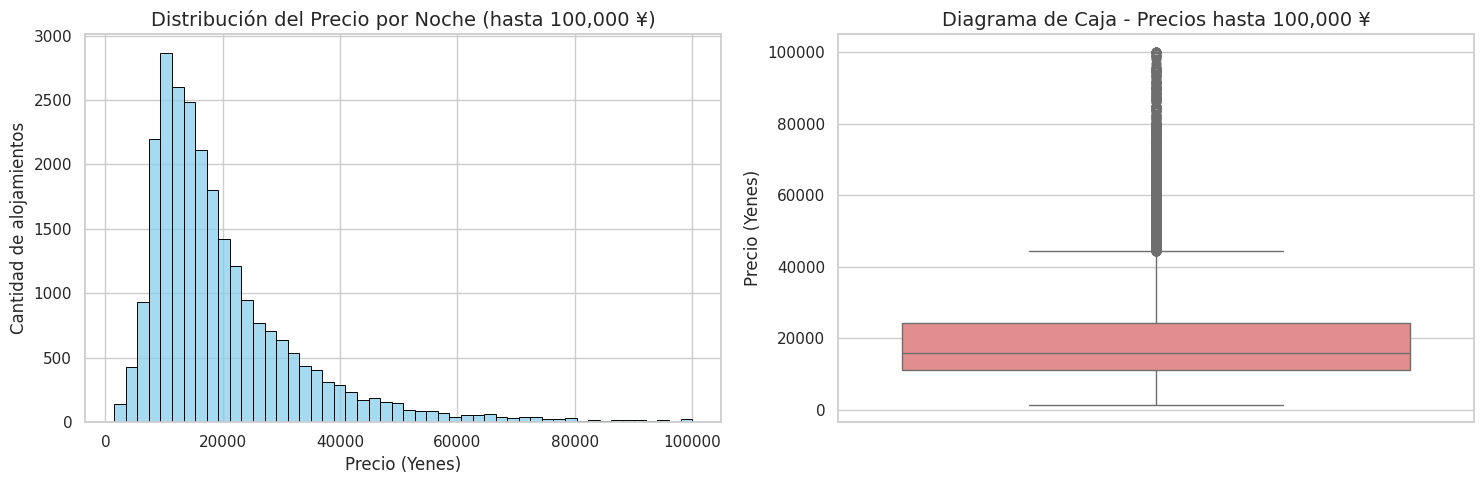

📊 ESTADÍSTICOS DE LA VARIABLE 'PRICE' (DATASET COMPLETO)
Media (Promedio):   24,780.81 Yenes
Mediana:            16,200.00 Yenes
Desvío Estándar:    77,878.81 Yenes
Mínimo:             1,500.00 Yenes
Máximo:             9,999,998.00 Yenes
Percentil 99%:      149,036.80 Yenes


In [58]:
# =============================================================================
# PASO 3.1: Análisis Univariado de la Variable Objetivo (price)
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 5)

# FILTRAMOS para visualizar (no borramos del DataFrame original)
# Tomamos solo los precios menores a 100,000 yenes (el 99% del mercado)
precios_visibles = df[df['price'] <= 100000]['price']

# Creamos una figura con 2 gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histograma (ahora sí se verá la distribución real)
sns.histplot(precios_visibles, bins=50, kde=False, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribución del Precio por Noche (hasta 100,000 ¥)', fontsize=14)
axes[0].set_xlabel('Precio (Yenes)')
axes[0].set_ylabel('Cantidad de alojamientos')

# 2. Boxplot (también filtrado para ver los cuartiles reales)
sns.boxplot(y=precios_visibles, ax=axes[1], color='lightcoral')
axes[1].set_title('Diagrama de Caja - Precios hasta 100,000 ¥', fontsize=14)
axes[1].set_ylabel('Precio (Yenes)')

plt.tight_layout()
plt.show()

# Mostramos los estadísticos básicos (del dataset COMPLETO, sin filtrar)
print("="*40)
print("📊 ESTADÍSTICOS DE LA VARIABLE 'PRICE' (DATASET COMPLETO)")
print("="*40)
print(f"Media (Promedio):   {df['price'].mean():,.2f} Yenes")
print(f"Mediana:            {df['price'].median():,.2f} Yenes")
print(f"Desvío Estándar:    {df['price'].std():,.2f} Yenes")
print(f"Mínimo:             {df['price'].min():,.2f} Yenes")
print(f"Máximo:             {df['price'].max():,.2f} Yenes")
print(f"Percentil 99%:      {df['price'].quantile(0.99):,.2f} Yenes")

Filtramos los precios mayores a 100,000 yenes SOLO para la visualización, porque había outliers extremos (hasta 10 millones) que comprimían el histograma y no nos dejaban ver la distribución real del mercado estándar de Tokio. El DataFrame original quedó intacto.

Buscamos los percentiles 95 y 99 para poder tomar una decisión respecto a los valores extremos

In [59]:
# Calculamos los percentiles 95 y 99
limite_95 = df['price'].quantile(0.95)
limite_99 = df['price'].quantile(0.99)

print(f"📊 Límite del 95% de los datos (Percentil 95): {limite_95:,.2f} Yenes")
print(f"📊 Límite del 99% de los datos (Percentil 99): {limite_99:,.2f} Yenes")

📊 Límite del 95% de los datos (Percentil 95): 51,610.00 Yenes
📊 Límite del 99% de los datos (Percentil 99): 149,036.80 Yenes


Buscamos y observamos la cantidad de propiedades que tienen un precio por encima del percentil 95

In [60]:
# Encontramos el precio máximo
precio_maximo = 50000
print(f"💰 Precio máximo en el dataset: {precio_maximo:,.2f} Yenes\n")

# Filtramos las filas que tienen ese precio exacto
filas_precio_maximo = df[df['price'] >= precio_maximo]

# Mostramos la tabla completa de esas filas
display(filas_precio_maximo)

# Contamos cuántas son
print(f"\n📊 Cantidad de alojamientos con el precio máximo: {len(filas_precio_maximo)}")

💰 Precio máximo en el dataset: 50,000.00 Yenes



,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
23,2027932,"Roppongi Villa,7min/ROPPONGIstatn.",10415965,Azabu,Distrito Especial,Minato,35.658190,139.727220,Entire home/apt,118572.0,5,170,1.19,3,1,1,M130001980
37,3085134,"""HirooHouse""3Rm, 6 guests, 2minWalk/HIROO Stn.",10415965,Azabu,Distrito Especial,Shibuya,35.651740,139.721750,Entire home/apt,50080.0,5,169,1.23,3,230,10,M130003771
56,3838856,SHINJUKU ★Designer Pencil House★ Airport Transfer,4626879,Tracey,Distrito Especial,Shibuya,35.682450,139.690090,Entire home/apt,63196.0,1,245,1.82,9,291,12,M130018884
61,3920124,"Residential area, Peaceful Traditional House 2",20307199,Hotaka,Ciudad,Higashimurayama,35.765770,139.446780,Entire home/apt,57059.0,15,134,1.06,3,364,1,M130000495
105,5585604,Sophiearth Annex with Two Bed Room,25865449,Seungkwan,Distrito Especial,Shinjuku,35.700410,139.706210,Private room,62958.0,3,15,0.12,10,91,1,Hotels and Inns Business Act | 東京都新宿区保健所 | 26新...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27851,1513579118541202770,3 min. walk from the sta! Easy access to Ginza...,560594175,圭太,Distrito Especial,Minato,35.668570,139.738690,Entire home/apt,500000.0,30,0,0.00,56,172,0,M130055733
27858,1513949070139182326,101东京中心-池袋超级商圈，全新高品质，北池袋站步行2分,690660167,磊,Distrito Especial,Toshima,35.739300,139.716850,Entire home/apt,115748.0,1,0,0.00,19,364,0,M130021509
27873,1514882548355623462,浅草の中心で『暮らすように泊まる』キッチン付きホテル（最大6名宿泊可能）,677460504,Asakusa,Distrito Especial,Taito,35.711220,139.797980,Private room,91000.0,1,0,0.00,3,309,0,Hotels and Inns Business Act | 東京都台東区台東保健所 | 6...
27905,1517045941383411532,有風小院 Yu fu sho in,720579622,優希,Distrito Especial,Kita,35.767595,139.714655,Entire home/apt,61207.0,1,0,0.00,1,365,0,Sin licencia



📊 Cantidad de alojamientos con el precio máximo: 1396


### Tratamiento de outliers

Realizamos Trimming a los datos que tienen un precio por encima del percentil 99 para evitar sesgar el modelo

In [61]:
# =============================================================================
# PASO 3.2: TRIMMING (Recorte de Outliers Extremos)
# =============================================================================

# Decisión de negocio: Eliminamos el 1% superior (precios > 148,913 yenes)
limite_p95 = df['price'].quantile(0.95)
#print(f"📊 Aplicando Trimming con Percentil 95: {limite_p95:,.2f} Yenes")
print("Viejo percentil 95=", limite_p95)
# Filtramos el DataFrame
filas_antes = len(df)
df = df[df['price'] < limite_p95]
#filas_despues = len(df)

# Decisión de negocio: Eliminamos el minimo de noches de 365
print(f"📊 Aplicando Trimming a minimum_nights")

# Eliminamos solo los que piden exactamente 365 días (o más)
df = df[df['minimum_nights'] > 0]
df = df[df['minimum_nights'] < 365]
print(f"✅ Filtrados alojamientos de 1 año. Filas restantes: {len(df)}")


filas_despues = len(df)

limite_p95 = df['price'].quantile(0.95)
print("Nuevo percentil 95=", limite_p95 )


print(f"✅ Filas eliminadas: {filas_antes - filas_despues}")
print(f"📊 Filas restantes: {filas_despues} (Mercado estándar + premium de Tokio)")

Viejo percentil 95= 51610.0
📊 Aplicando Trimming a minimum_nights
✅ Filtrados alojamientos de 1 año. Filas restantes: 24196
Nuevo percentil 95= 39132.5
✅ Filas eliminadas: 1275
📊 Filas restantes: 24196 (Mercado estándar + premium de Tokio)


Vemos que la cantidad de filas eliminadas coincide con la cantidad de datos que tenian un precio mayor al percentil 99

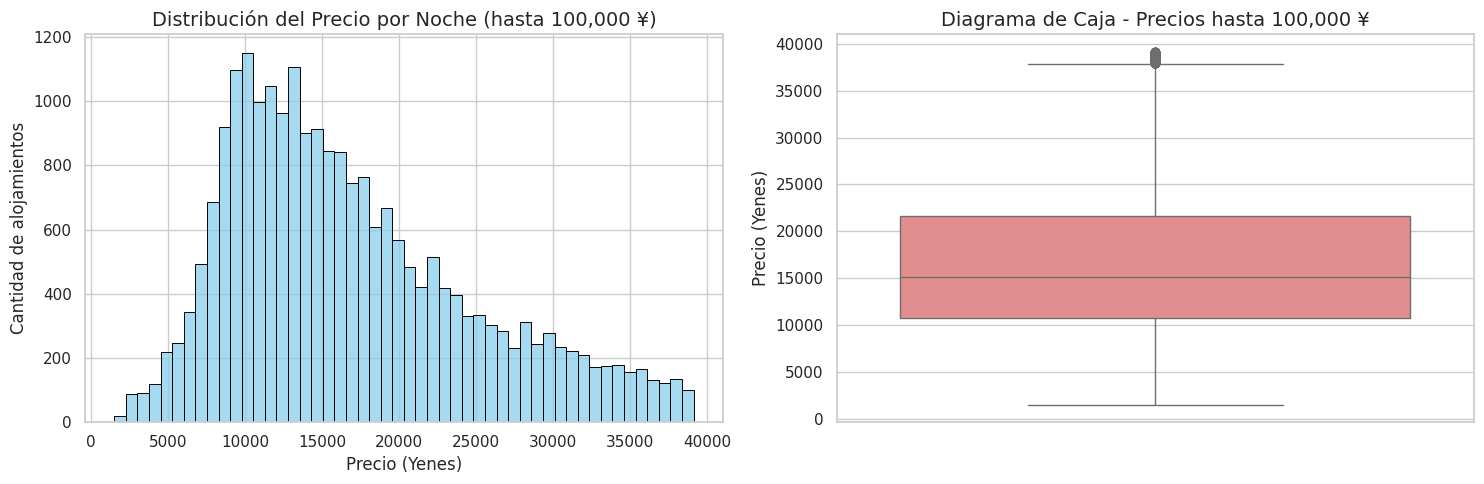

📊 ESTADÍSTICOS DE LA VARIABLE 'PRICE' (DATASET COMPLETO)
Media (Promedio):   18,269.83 Yenes
Mediana:            15,715.00 Yenes
Desvío Estándar:    9,863.74 Yenes
Mínimo:             1,500.00 Yenes
Máximo:             51,608.00 Yenes
Percentil 99%:      48,000.00 Yenes


In [62]:
# =============================================================================
# Análisis Univariado de la Variable Objetivo (price) despues de auditación y eliminación de outliers
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 5)

# FILTRAMOS para visualizar (no borramos del DataFrame original)
# Tomamos solo los precios menores a 100,000 yenes (el 99% del mercado)
precios_visibles = df[df['price'] <= limite_p95]['price']

# Creamos una figura con 2 gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histograma (ahora sí se verá la distribución real)
sns.histplot(precios_visibles, bins=50, kde=False, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribución del Precio por Noche (hasta 100,000 ¥)', fontsize=14)
axes[0].set_xlabel('Precio (Yenes)')
axes[0].set_ylabel('Cantidad de alojamientos')

# 2. Boxplot (también filtrado para ver los cuartiles reales)
sns.boxplot(y=precios_visibles, ax=axes[1], color='lightcoral')
axes[1].set_title('Diagrama de Caja - Precios hasta 100,000 ¥', fontsize=14)
axes[1].set_ylabel('Precio (Yenes)')

plt.tight_layout()
plt.show()

# Mostramos los estadísticos básicos (del dataset COMPLETO, sin filtrar)
print("="*40)
print("📊 ESTADÍSTICOS DE LA VARIABLE 'PRICE' (DATASET COMPLETO)")
print("="*40)
print(f"Media (Promedio):   {df['price'].mean():,.2f} Yenes")
print(f"Mediana:            {df['price'].median():,.2f} Yenes")
print(f"Desvío Estándar:    {df['price'].std():,.2f} Yenes")
print(f"Mínimo:             {df['price'].min():,.2f} Yenes")
print(f"Máximo:             {df['price'].max():,.2f} Yenes")
print(f"Percentil 99%:      {df['price'].quantile(0.99):,.2f} Yenes")

Elegimos el percentil 95 porque queríamos enfocarnos en el mercado estándar de Airbnb en Tokio. El percentil 99 incluía propiedades de ultra-lujo (hasta 148,000 yenes) que no son representativas del turista promedio. Con P95, nuestro modelo va a predecir precios para el 95% del mercado real, que es lo que la mayoría de los usuarios buscan."

📊 DISTRIBUCIÓN DE TIPOS DE HABITACIÓN:
room_type
Entire home/apt    20916
Private room        2940
Shared room          253
Hotel room            87
Name: count, dtype: int64

📈 PORCENTAJES:
room_type
Entire home/apt    86.44
Private room       12.15
Shared room         1.05
Hotel room          0.36
Name: proportion, dtype: float64


/tmp/ipykernel_9998/3387057142.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='room_type', palette='viridis', order=df['room_type'].value_counts().index)


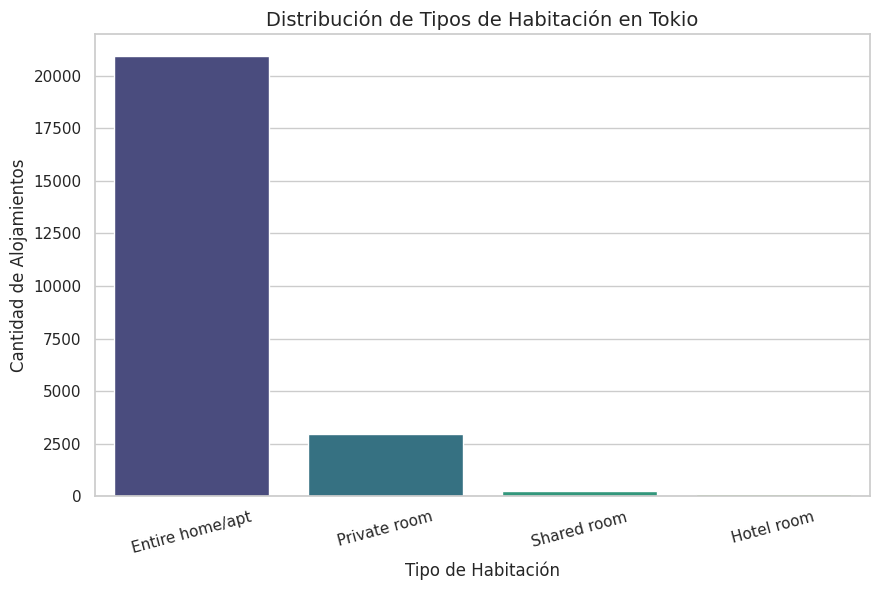

In [63]:
# =============================================================================
# PASO 3.3: Análisis Univariado de room_type
# =============================================================================

# 1. Conteo de categorías
print("📊 DISTRIBUCIÓN DE TIPOS DE HABITACIÓN:")
print("="*60)
conteo_room_type = df['room_type'].value_counts()
print(conteo_room_type)

# 2. Porcentajes
print("\n📈 PORCENTAJES:")
print("="*60)
porcentajes = (df['room_type'].value_counts(normalize=True) * 100).round(2)
print(porcentajes)

# 3. Gráfico de barras
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='room_type', palette='viridis', order=df['room_type'].value_counts().index)
plt.title('Distribución de Tipos de Habitación en Tokio', fontsize=14)
plt.xlabel('Tipo de Habitación', fontsize=12)
plt.ylabel('Cantidad de Alojamientos', fontsize=12)
plt.xticks(rotation=15)
plt.show()

Desequilibrio de clases: Vemos que "Entire home/apt" domina completamente el dataset (probablemente más del 80%). Esto es importante porque:

*Las categorías minoritarias ("Shared room", "Hotel room") van a tener menos datos para entrenar el modelo.

*Detectamos un desbalance de clases en room_type, donde los departamentos enteros dominan el mercado de Tokio.

*Contexto de negocio: Esto tiene mucho sentido en Tokio, donde la mayoría de los turistas buscan privacidad y prefieren alquilar departamentos completos.


📊 DISTRIBUCIÓN DE TIPOS DE ZONA GEOGRÁFICA:
neighbourhood_group
Distrito Especial    23698
Ciudad                 498
Name: count, dtype: int64

📈 PORCENTAJES:
neighbourhood_group
Distrito Especial    97.94
Ciudad                2.06
Name: proportion, dtype: float64


/tmp/ipykernel_9998/2152765607.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='neighbourhood_group', palette='viridis', order=df['neighbourhood_group'].value_counts().index)


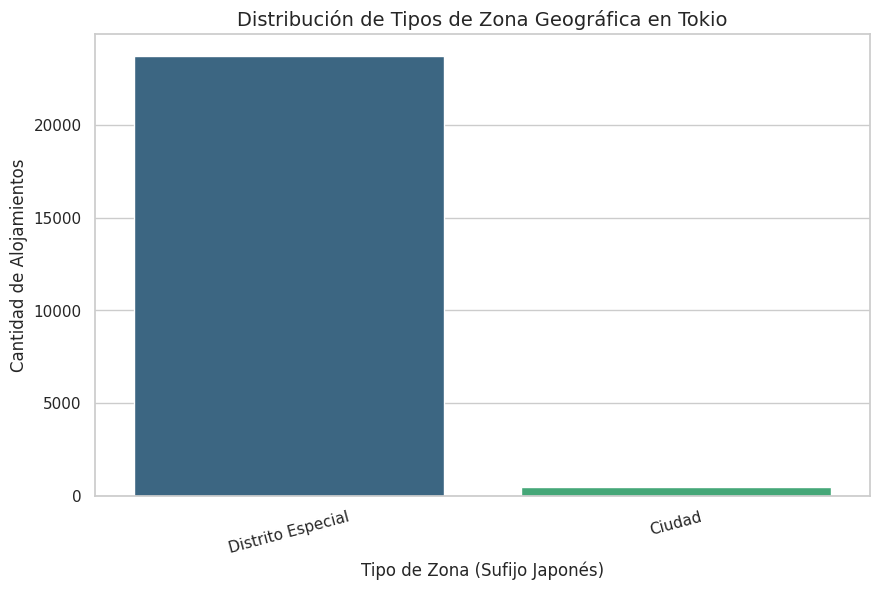

In [64]:
# =============================================================================
# PASO 3.4: Análisis Univariado de neighbourhood_group (Sufijos Japoneses)
# =============================================================================

# 1. Conteo de categorías
print("📊 DISTRIBUCIÓN DE TIPOS DE ZONA GEOGRÁFICA:")
print("="*60)
conteo_neighbourhood_group = df['neighbourhood_group'].value_counts()
print(conteo_neighbourhood_group)

# 2. Porcentajes
print("\n📈 PORCENTAJES:")
print("="*60)
porcentajes = (df['neighbourhood_group'].value_counts(normalize=True) * 100).round(2)
print(porcentajes)

# 3. Gráfico de barras
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='neighbourhood_group', palette='viridis', order=df['neighbourhood_group'].value_counts().index)
plt.title('Distribución de Tipos de Zona Geográfica en Tokio', fontsize=14)
plt.xlabel('Tipo de Zona (Sufijo Japonés)', fontsize=12)
plt.ylabel('Cantidad de Alojamientos', fontsize=12)
plt.xticks(rotation=15)
plt.show()

El 97.91% de los alojamientos están en distritos especiales (Ku) porque son las zonas céntricas y turísticas de Tokio. Las categorías 'Villa' y 'Pueblo' representan menos del 1% y corresponden a islas remotas del archipiélago de Tokio. Esto nos indica que el mercado de Airbnb en Tokio es casi completamente urbano

Implicancia para el modelo: Cuando hagamos el One-Hot Encoding (convertir estas categorías a columnas numéricas), vamos a tener muchas columnas con muy pocos datos. Esto puede hacer que el modelo no aprenda bien patrones para "Villa" o "Pueblo".

### Análisis de las variables numéricas restantes

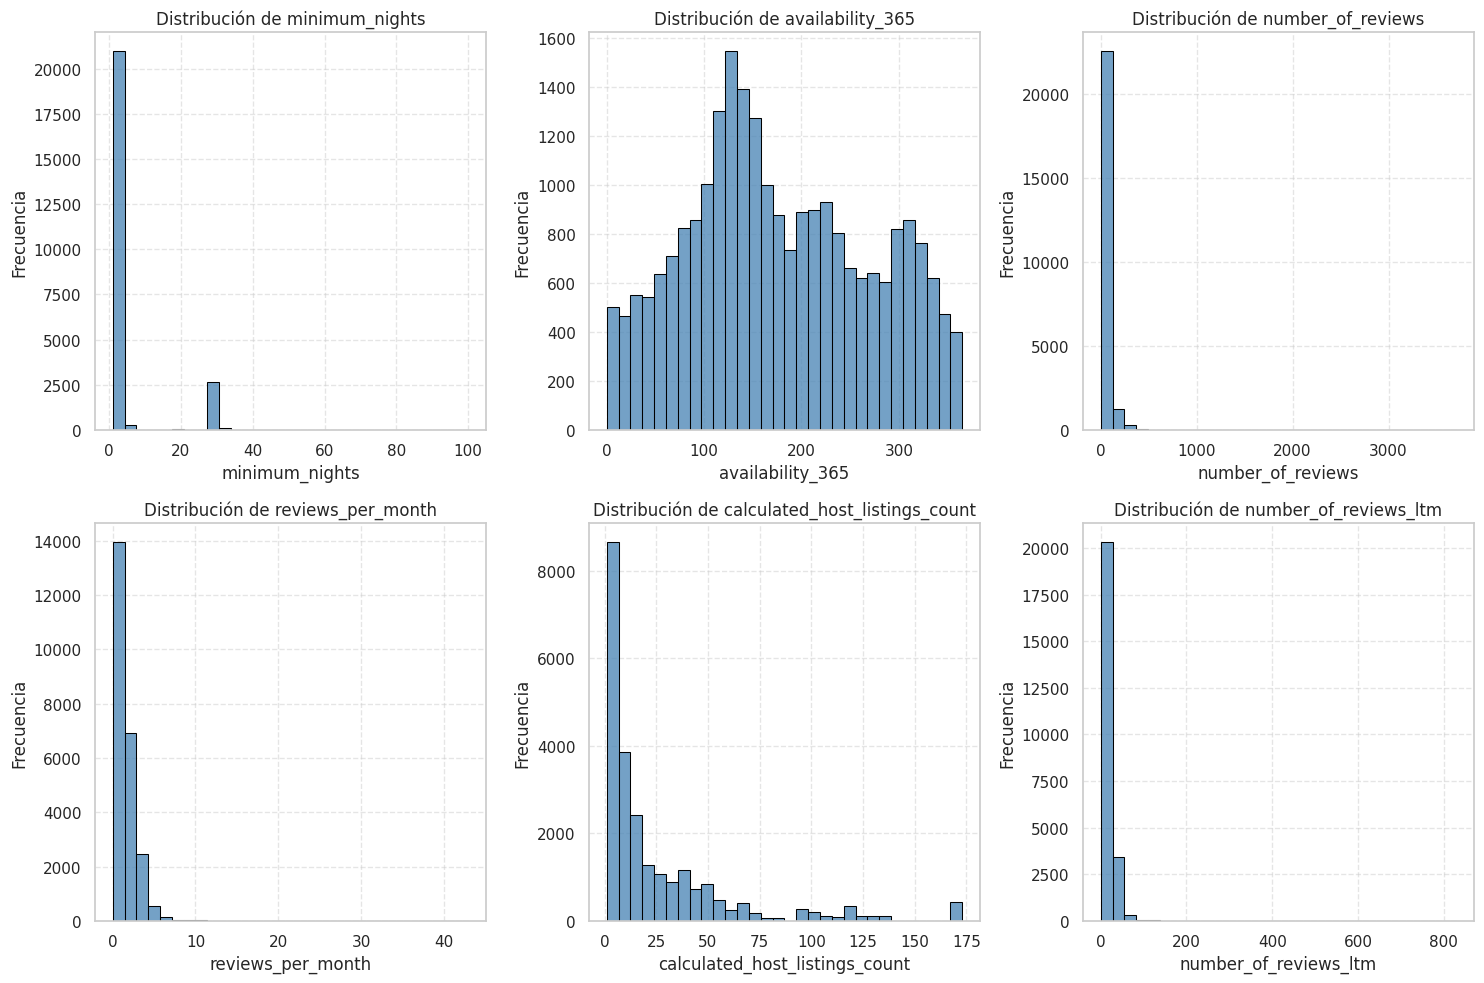

📊 RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS
       minimum_nights  availability_365  number_of_reviews  reviews_per_month  \
count    24196.000000      24196.000000       24196.000000       24196.000000   
mean         5.024673        177.273020          37.176765           1.492767   
std          9.198242         93.398353          68.507405           1.575211   
min          1.000000          0.000000           0.000000           0.000000   
25%          1.000000        109.000000           3.000000           0.450000   
50%          2.000000        164.000000          17.000000           1.180000   
75%          2.000000        251.000000          44.000000           2.120000   
max        100.000000        365.000000        3705.000000          42.950000   

       calculated_host_listings_count  number_of_reviews_ltm  
count                    24196.000000           24196.000000  
mean                        25.752976              13.925566  
std                         34.61750

In [65]:
# =============================================================================
# PASO 3.5: Análisis Univariado Express de Variables Numéricas
# =============================================================================

# Lista de variables numéricas a analizar
variables_numericas = [
    'minimum_nights',
    'availability_365',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'number_of_reviews_ltm'
]

# Creamos una grilla de 2x3 para los 6 histogramas
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Graficamos cada variable
for i, var in enumerate(variables_numericas):
    sns.histplot(df[var], bins=30, kde=False, ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribución de {var}', fontsize=12)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Resumen estadístico de todas las variables
print("="*70)
print("📊 RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS")
print("="*70)
print(df[variables_numericas].describe())

Lo que vemos:

number_of_reviews (muchos ceros): Son alojamientos nuevos que nunca recibieron huéspedes. No hay que borrarlos.

reviews_per_month (muchos ceros): Mismo motivo. Si nunca tuvo reseñas, tiene 0 reseñas por mes. Ya lo rellenamos con 0 en la limpieza.

number_of_reviews_ltm (muchos ceros): Son los "anuncios zombies": propiedades que quizás tuvieron reseñas hace años pero en los últimos 12 meses nadie las reservó.

availability 365:

*Distribución más uniforme de lo esperado

*Picos en ~120-150 días y ~300-330 días: Dos grupos claros

*No hay pico en 0: Sorprendente, significa que pocos anuncios están completamente bloqueados

*No hay pico en 365: Pocos anuncios están siempre disponibles

minimum_nights:

*1-2 noches (Mediana = 2, 75% ≤ 2 noches)
Mercado turístico puro: Anfitriones flexibles que aceptan estancias cortas
Estrategia: Maximizar ocupación con rotación constante
Perfil: Turistas de fin de semana, viajes de negocios, escalas
3-7 noches
Estancia media: Turistas que buscan conocer Tokio con calma
Equilibrio: Menos rotación pero ingresos más estables

8-30 noches (12.97% del mercado)
Alquiler temporal: Estudiantes, trabajadores por proyecto, familias en transición
Ingresos: Menor rotación, menor limpieza, pero ingreso garantizado

Mayor a 30 noches (0.74% del mercado)
Alquiler de larga estancia: Prácticamente un contrato de alquiler tradicional
Outliers de 365: Probablemente errores de carga o propiedades bloqueadas

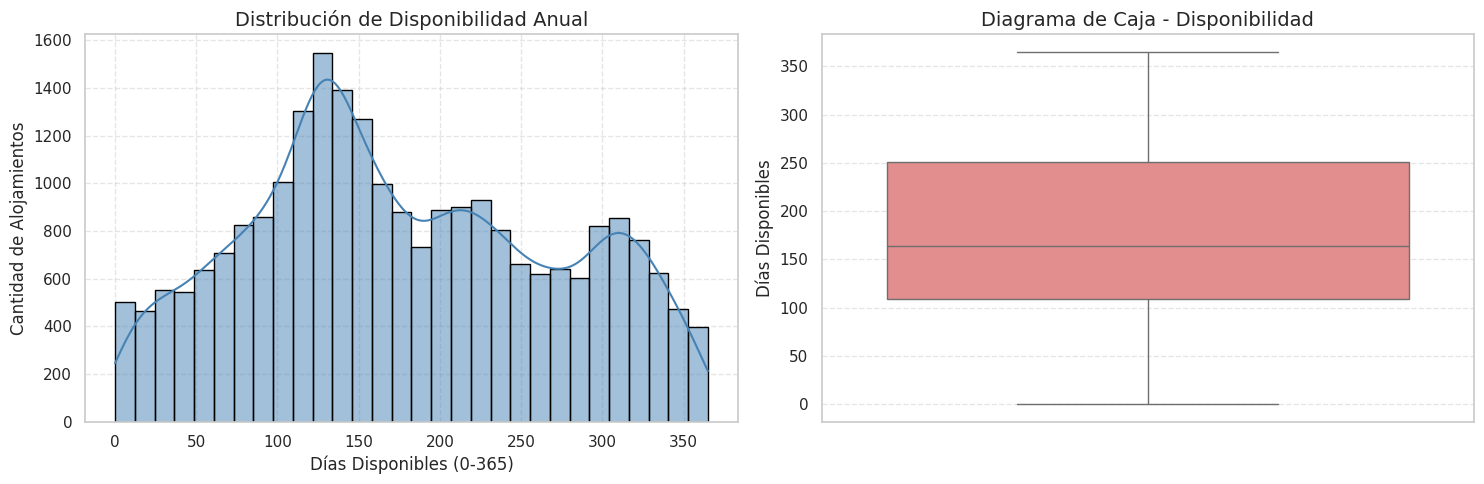

📊 RESUMEN ESTADÍSTICO DE availability_365
Media:              177.27 días
Mediana:            164.00 días
Desvío Estándar:    93.40 días
Mínimo:             0 días
Máximo:             365 días

Percentil 25%:      109 días
Percentil 50%:      164 días
Percentil 75%:      251 días

📈 DISTRIBUCIÓN POR CATEGORÍAS CLAVE:
📍 Disponibilidad 0 días (Bloqueados):     73 (0.3%)
📍 Disponibilidad baja (1-90 días):        4535 (18.7%)
📍 Disponibilidad media (91-180 días):     8727 (36.1%)
📍 Disponibilidad alta (181-364 días):     10808 (44.7%)
📍 Disponibilidad 365 días (Siempre libre):53 (0.2%)


In [66]:
# =============================================================================
# PASO 3.6: Análisis Univariado de availability_365
# =============================================================================

# Configuración visual
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histograma (Para ver la distribución completa)
sns.histplot(df['availability_365'], bins=30, kde=True, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de Disponibilidad Anual', fontsize=14)
axes[0].set_xlabel('Días Disponibles (0-365)', fontsize=12)
axes[0].set_ylabel('Cantidad de Alojamientos', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Boxplot (Para ver cuartiles y outliers)
sns.boxplot(y=df['availability_365'], ax=axes[1], color='lightcoral')
axes[1].set_title('Diagrama de Caja - Disponibilidad', fontsize=14)
axes[1].set_ylabel('Días Disponibles', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.show()

# Estadísticos descriptivos
print("="*60)
print("📊 RESUMEN ESTADÍSTICO DE availability_365")
print("="*60)
print(f"Media:              {df['availability_365'].mean():.2f} días")
print(f"Mediana:            {df['availability_365'].median():.2f} días")
print(f"Desvío Estándar:    {df['availability_365'].std():.2f} días")
print(f"Mínimo:             {df['availability_365'].min()} días")
print(f"Máximo:             {df['availability_365'].max()} días")
print(f"\nPercentil 25%:      {df['availability_365'].quantile(0.25):.0f} días")
print(f"Percentil 50%:      {df['availability_365'].quantile(0.50):.0f} días")
print(f"Percentil 75%:      {df['availability_365'].quantile(0.75):.0f} días")

# Conteo de valores clave
print("\n" + "="*60)
print("📈 DISTRIBUCIÓN POR CATEGORÍAS CLAVE:")
print("="*60)
disponibilidad_0 = (df['availability_365'] == 0).sum()
disponibilidad_365 = (df['availability_365'] == 365).sum()
disponibilidad_baja = ((df['availability_365'] > 0) & (df['availability_365'] <= 90)).sum()
disponibilidad_media = ((df['availability_365'] > 90) & (df['availability_365'] <= 180)).sum()
disponibilidad_alta = ((df['availability_365'] > 180) & (df['availability_365'] < 365)).sum()

print(f"📍 Disponibilidad 0 días (Bloqueados):     {disponibilidad_0} ({disponibilidad_0/len(df)*100:.1f}%)")
print(f"📍 Disponibilidad baja (1-90 días):        {disponibilidad_baja} ({disponibilidad_baja/len(df)*100:.1f}%)")
print(f"📍 Disponibilidad media (91-180 días):     {disponibilidad_media} ({disponibilidad_media/len(df)*100:.1f}%)")
print(f"📍 Disponibilidad alta (181-364 días):     {disponibilidad_alta} ({disponibilidad_alta/len(df)*100:.1f}%)")
print(f"📍 Disponibilidad 365 días (Siempre libre):{disponibilidad_365} ({disponibilidad_365/len(df)*100:.1f}%)")

Explicación especifica de availability_365: En el análisis de availability_365 detectamos que solo el 0.5% de los alojamientos están en los extremos (0 o 365 días). A diferencia de otras ciudades donde hay muchos 'anuncios zombies', en Tokio los anfitriones gestionan sus calendarios de forma muy activa. Por eso decidimos conservar todos los datos y dejar la variable como numérica continua para el modelo.

## Analisis Bivariado

/tmp/ipykernel_9998/2943393606.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='room_type', y='price', palette='viridis')


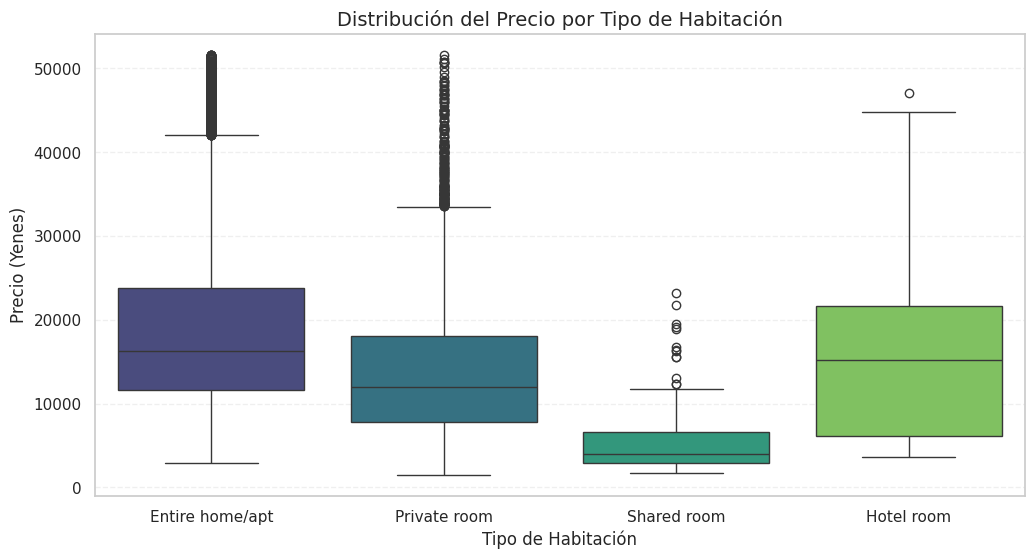

📊 ESTADÍSTICOS DE PRECIO POR TIPO DE HABITACIÓN


,Cantidad,Media,Mediana,Mínimo,Máximo,Desvío Estándar
room_type,,,,,,
Entire home/apt,20916,18953.02,16215.0,2900.0,51608.0,9741.52
Hotel room,87,15994.90,15158.0,3566.0,47028.0,10500.86
Private room,2940,14608.86,12000.0,1500.0,51572.0,9462.15
Shared room,253,5113.90,3990.0,1700.0,23143.0,3571.53



💰 PRECIO PROMEDIO POR TIPO DE HABITACIÓN
room_type
Entire home/apt    18953.024909
Hotel room         15994.896552
Private room       14608.864286
Shared room         5113.897233
Name: price, dtype: float64


/tmp/ipykernel_9998/2943393606.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=precio_promedio.index, y=precio_promedio.values, palette='viridis')


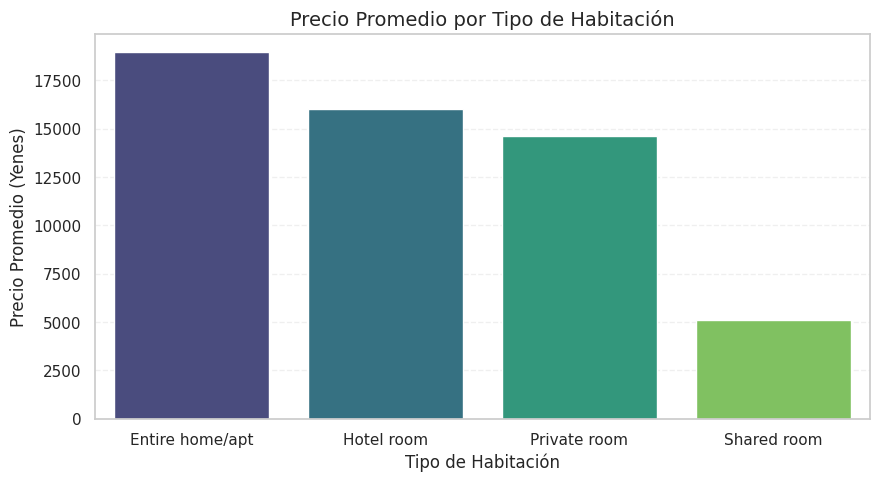

In [67]:
# =============================================================================
# PASO 3.7: Análisis Bivariado - room_type vs price
# =============================================================================

# Configuración visual
plt.figure(figsize=(12, 6))

# 1. Boxplot: Distribución de precios por tipo de habitación
sns.boxplot(data=df, x='room_type', y='price', palette='viridis')
plt.title('Distribución del Precio por Tipo de Habitación', fontsize=14)
plt.xlabel('Tipo de Habitación', fontsize=12)
plt.ylabel('Precio (Yenes)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.show()

# 2. Estadísticos por categoría
print("="*70)
print("📊 ESTADÍSTICOS DE PRECIO POR TIPO DE HABITACIÓN")
print("="*70)
estadisticos_room_type = df.groupby('room_type')['price'].agg([
    ('Cantidad', 'count'),
    ('Media', 'mean'),
    ('Mediana', 'median'),
    ('Mínimo', 'min'),
    ('Máximo', 'max'),
    ('Desvío Estándar', 'std')
]).round(2)

display(estadisticos_room_type)

# 3. Precio promedio por categoría (gráfico de barras)
print("\n" + "="*70)
print("💰 PRECIO PROMEDIO POR TIPO DE HABITACIÓN")
print("="*70)
precio_promedio = df.groupby('room_type')['price'].mean().sort_values(ascending=False)
print(precio_promedio)

plt.figure(figsize=(10, 5))
sns.barplot(x=precio_promedio.index, y=precio_promedio.values, palette='viridis')
plt.title('Precio Promedio por Tipo de Habitación', fontsize=14)
plt.xlabel('Tipo de Habitación', fontsize=12)
plt.ylabel('Precio Promedio (Yenes)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.show()

El análisis bivariado muestra que el tipo de habitación es el predictor más fuerte del precio. Los departamentos enteros cuestan en promedio el doble que las habitaciones privadas, y 4-5 veces más que las compartidas. Esto tiene sentido lógico: un turista que alquila un departamento completo paga por privacidad y espacio, mientras que una habitación compartida es para mochileros con presupuesto limitado.

Hallazgos Clave:

*Entire home/apt es el tipo más común y caro

*Shared room tiene el precio más bajo (como se esperaba)

*La diferencia entre media y mediana sugiere presencia de outliers (precios muy altos)

*Hotel room tiene poca representación en el dataset

/tmp/ipykernel_9998/1541150762.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='neighbourhood_group', y='price', ax=axes[0], palette='viridis')
/tmp/ipykernel_9998/1541150762.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=precio_promedio_zona.index, y=precio_promedio_zona.values, ax=axes[1], palette='viridis')


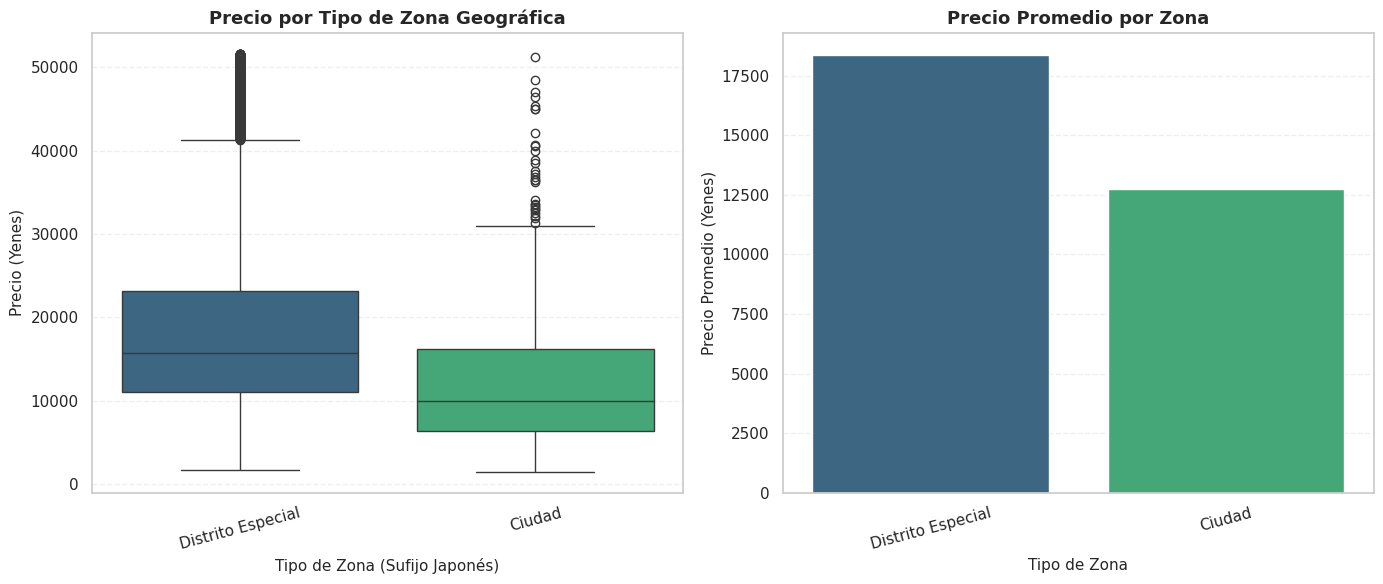

📊 ESTADÍSTICOS DE PRECIO POR TIPO DE ZONA GEOGRÁFICA


,Cantidad,Media,Mediana,Mínimo,Máximo
neighbourhood_group,,,,,
Ciudad,498,12751.28,9993.5,1500.0,51250.0
Distrito Especial,23698,18385.80,15777.0,1700.0,51608.0


In [68]:
# =============================================================================
# ANÁLISIS BIVARIADO: neighbourhood_group vs price
# =============================================================================

# Configuración visual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Boxplot: Distribución de precios por tipo de zona
sns.boxplot(data=df, x='neighbourhood_group', y='price', ax=axes[0], palette='viridis')
axes[0].set_title('Precio por Tipo de Zona Geográfica', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tipo de Zona (Sufijo Japonés)', fontsize=11)
axes[0].set_ylabel('Precio (Yenes)', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, linestyle='--', alpha=0.3, axis='y')

# 2. Precio promedio por zona
precio_promedio_zona = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
sns.barplot(x=precio_promedio_zona.index, y=precio_promedio_zona.values, ax=axes[1], palette='viridis')
axes[1].set_title('Precio Promedio por Zona', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tipo de Zona', fontsize=11)
axes[1].set_ylabel('Precio Promedio (Yenes)', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, linestyle='--', alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Estadísticos por categoría
print("="*70)
print("📊 ESTADÍSTICOS DE PRECIO POR TIPO DE ZONA GEOGRÁFICA")
print("="*70)
estadisticos_zona = df.groupby('neighbourhood_group')['price'].agg([
    ('Cantidad', 'count'),
    ('Media', 'mean'),
    ('Mediana', 'median'),
    ('Mínimo', 'min'),
    ('Máximo', 'max')
]).round(2)

display(estadisticos_zona)

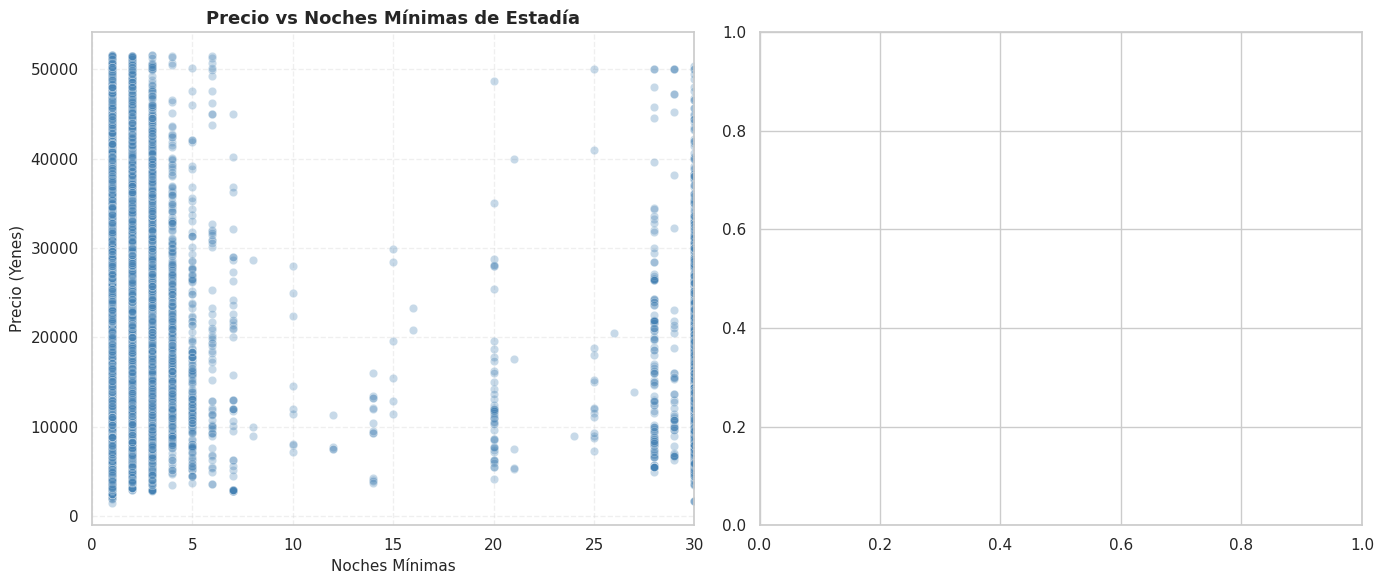

📊 CORRELACIÓN ENTRE minimum_nights Y price
Coeficiente de correlación de Pearson: -0.158
➡️  Interpretación: Sin correlación significativa

📊 PRECIO PROMEDIO POR DURACIÓN MÍNIMA
nights_category
1-2 noches     18784.33
3-7 noches     19441.61
8-30 noches    13892.08
Name: price, dtype: float64


In [69]:
# =============================================================================
# ANÁLISIS BIVARIADO: minimum_nights vs price
# =============================================================================

# Configuración visual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Scatter plot: Relación entre noches mínimas y precio
sns.scatterplot(data=df, x='minimum_nights', y='price', ax=axes[0], alpha=0.3, color='steelblue')
axes[0].set_title('Precio vs Noches Mínimas de Estadía', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Noches Mínimas', fontsize=11)
axes[0].set_ylabel('Precio (Yenes)', fontsize=11)
axes[0].set_xlim(0, 30)  # Limitamos para ver mejor el mercado turístico
axes[0].grid(True, linestyle='--', alpha=0.3)

# 2. Precio promedio por rango de noches
"""df['nights_category'] = pd.cut(df['minimum_nights'],
                                bins=[0, 2, 7, 30],
                                labels=['1-2 noches', '3-7 noches', '8-30 noches'])
precio_por_noches = df.groupby('nights_category')['price'].mean()
sns.barplot(x=precio_por_noches.index, y=precio_por_noches.values, ax=axes[1], palette='magma')
axes[1].set_title('Precio Promedio por Duración Mínima', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Categoría de Noches', fontsize=11)
axes[1].set_ylabel('Precio Promedio (Yenes)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.3, axis='y')"""

plt.tight_layout()
plt.show()

# Correlación
print("="*70)
print("📊 CORRELACIÓN ENTRE minimum_nights Y price")
print("="*70)
correlacion = df['minimum_nights'].corr(df['price'])
print(f"Coeficiente de correlación de Pearson: {correlacion:.3f}")

if correlacion < -0.3:
    print("📉 Interpretación: Correlación negativa moderada - Las estancias largas son más baratas")
elif correlacion > 0.3:
    print("📈 Interpretación: Correlación positiva moderada - Las estancias largas son más caras")
else:
    print("➡️  Interpretación: Sin correlación significativa")

# Estadísticos por categoría
print("\n" + "="*70)
print("📊 PRECIO PROMEDIO POR DURACIÓN MÍNIMA")
print("="*70)
print(precio_por_noches.round(2))

/tmp/ipykernel_9998/3449650886.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  precio_por_dispo = df.groupby('availability_category')['price'].mean()
/tmp/ipykernel_9998/3449650886.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=precio_por_dispo.index, y=precio_por_dispo.values, ax=axes[1], palette='coolwarm')


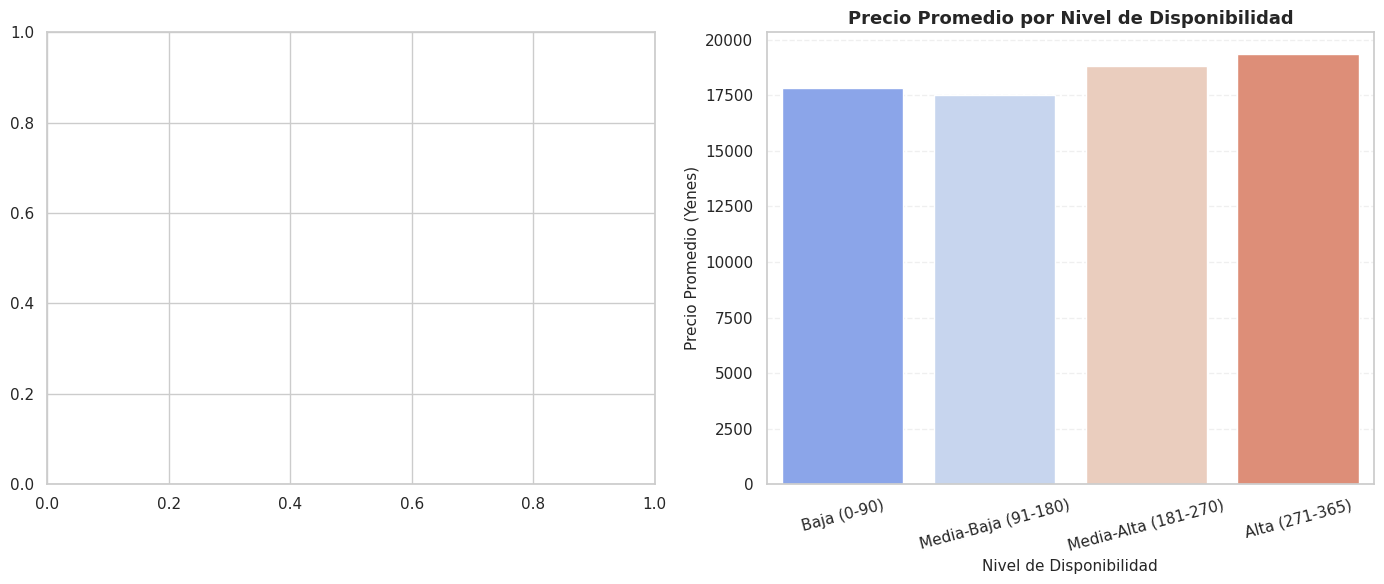

📊 CORRELACIÓN ENTRE availability_365 Y price
Coeficiente de correlación de Pearson: 0.071
➡️  Interpretación: Sin correlación significativa - La disponibilidad no afecta el precio

📊 PRECIO PROMEDIO POR NIVEL DE DISPONIBILIDAD
availability_category
Baja (0-90)             17820.86
Media-Baja (91-180)     17509.09
Media-Alta (181-270)    18830.99
Alta (271-365)          19373.56
Name: price, dtype: float64


In [70]:
# =============================================================================
# ANÁLISIS BIVARIADO: availability_365 vs price
# =============================================================================

# Configuración visual
fig, axes = plt.subplots(1, 2,  figsize=(14, 6))



# 2. Precio promedio por nivel de disponibilidad
df['availability_category'] = pd.cut(df['availability_365'],
                                      bins=[0, 90, 180, 270, 365],
                                      labels=['Baja (0-90)', 'Media-Baja (91-180)', 'Media-Alta (181-270)', 'Alta (271-365)'])
precio_por_dispo = df.groupby('availability_category')['price'].mean()
sns.barplot(x=precio_por_dispo.index, y=precio_por_dispo.values, ax=axes[1], palette='coolwarm')
axes[1].set_title('Precio Promedio por Nivel de Disponibilidad', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nivel de Disponibilidad', fontsize=11)
axes[1].set_ylabel('Precio Promedio (Yenes)', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, linestyle='--', alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Correlación
print("="*70)
print("📊 CORRELACIÓN ENTRE availability_365 Y price")
print("="*70)
correlacion = df['availability_365'].corr(df['price'])
print(f"Coeficiente de correlación de Pearson: {correlacion:.3f}")

if correlacion < -0.3:
    print("📉 Interpretación: Correlación negativa - Mayor disponibilidad = Menor precio (muy demandados)")
elif correlacion > 0.3:
    print("📈 Interpretación: Correlación positiva - Mayor disponibilidad = Mayor precio (inversión pura)")
else:
    print("➡️  Interpretación: Sin correlación significativa - La disponibilidad no afecta el precio")

# Estadísticos por categoría
print("\n" + "="*70)
print("📊 PRECIO PROMEDIO POR NIVEL DE DISPONIBILIDAD")
print("="*70)
print(precio_por_dispo.round(2))

/tmp/ipykernel_9998/4138973327.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  precio_por_reviews = df.groupby('popularity_category')['price'].mean()
/tmp/ipykernel_9998/4138973327.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=precio_por_reviews.index, y=precio_por_reviews.values, ax=axes[1], palette='viridis')


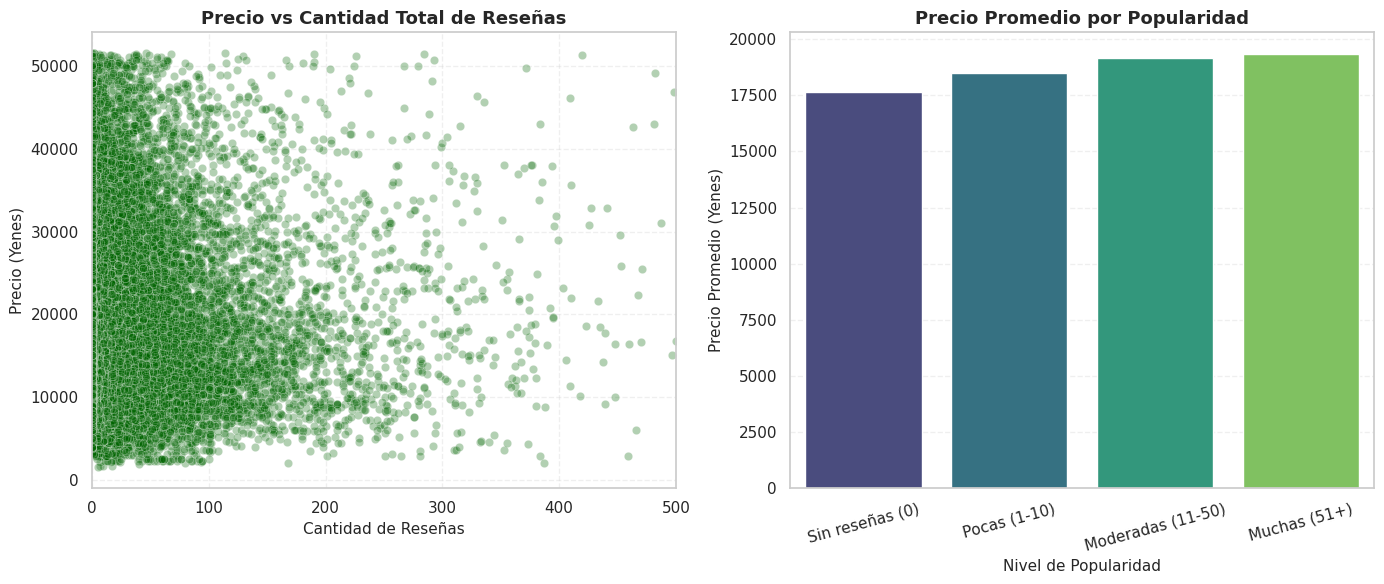

📊 CORRELACIÓN ENTRE number_of_reviews Y price
Coeficiente de correlación de Pearson: 0.047
➡️  Interpretación: Sin correlación significativa - La popularidad no determina el precio

📊 PRECIO PROMEDIO POR NIVEL DE POPULARIDAD
popularity_category
Sin reseñas (0)      17658.40
Pocas (1-10)         18481.10
Moderadas (11-50)    19168.78
Muchas (51+)         19337.58
Name: price, dtype: float64


In [71]:
# =============================================================================
# ANÁLISIS BIVARIADO: number_of_reviews vs price
# =============================================================================

# Configuración visual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Scatter plot: Relación entre reseñas y precio
sns.scatterplot(data=df, x='number_of_reviews', y='price', ax=axes[0], alpha=0.3, color='darkgreen')
axes[0].set_title('Precio vs Cantidad Total de Reseñas', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cantidad de Reseñas', fontsize=11)
axes[0].set_ylabel('Precio (Yenes)', fontsize=11)
axes[0].set_xlim(0, 500)  # Limitamos para ver mejor la tendencia
axes[0].grid(True, linestyle='--', alpha=0.3)

# 2. Precio promedio por nivel de popularidad
df['popularity_category'] = pd.cut(df['number_of_reviews'],
                                    bins=[0, 10, 50, 100, 5000],
                                    labels=['Sin reseñas (0)', 'Pocas (1-10)', 'Moderadas (11-50)', 'Muchas (51+)'])
precio_por_reviews = df.groupby('popularity_category')['price'].mean()
sns.barplot(x=precio_por_reviews.index, y=precio_por_reviews.values, ax=axes[1], palette='viridis')
axes[1].set_title('Precio Promedio por Popularidad', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nivel de Popularidad', fontsize=11)
axes[1].set_ylabel('Precio Promedio (Yenes)', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, linestyle='--', alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Correlación
print("="*70)
print("📊 CORRELACIÓN ENTRE number_of_reviews Y price")
print("="*70)
correlacion = df['number_of_reviews'].corr(df['price'])
print(f"Coeficiente de correlación de Pearson: {correlacion:.3f}")

if correlacion < -0.3:
    print("📉 Interpretación: Correlación negativa - Más reseñas = Menor precio (volumen vs calidad)")
elif correlacion > 0.3:
    print("📈 Interpretación: Correlación positiva - Más reseñas = Mayor precio (calidad premium)")
else:
    print("➡️  Interpretación: Sin correlación significativa - La popularidad no determina el precio")

# Estadísticos por categoría
print("\n" + "="*70)
print("📊 PRECIO PROMEDIO POR NIVEL DE POPULARIDAD")
print("="*70)
print(precio_por_reviews.round(2))

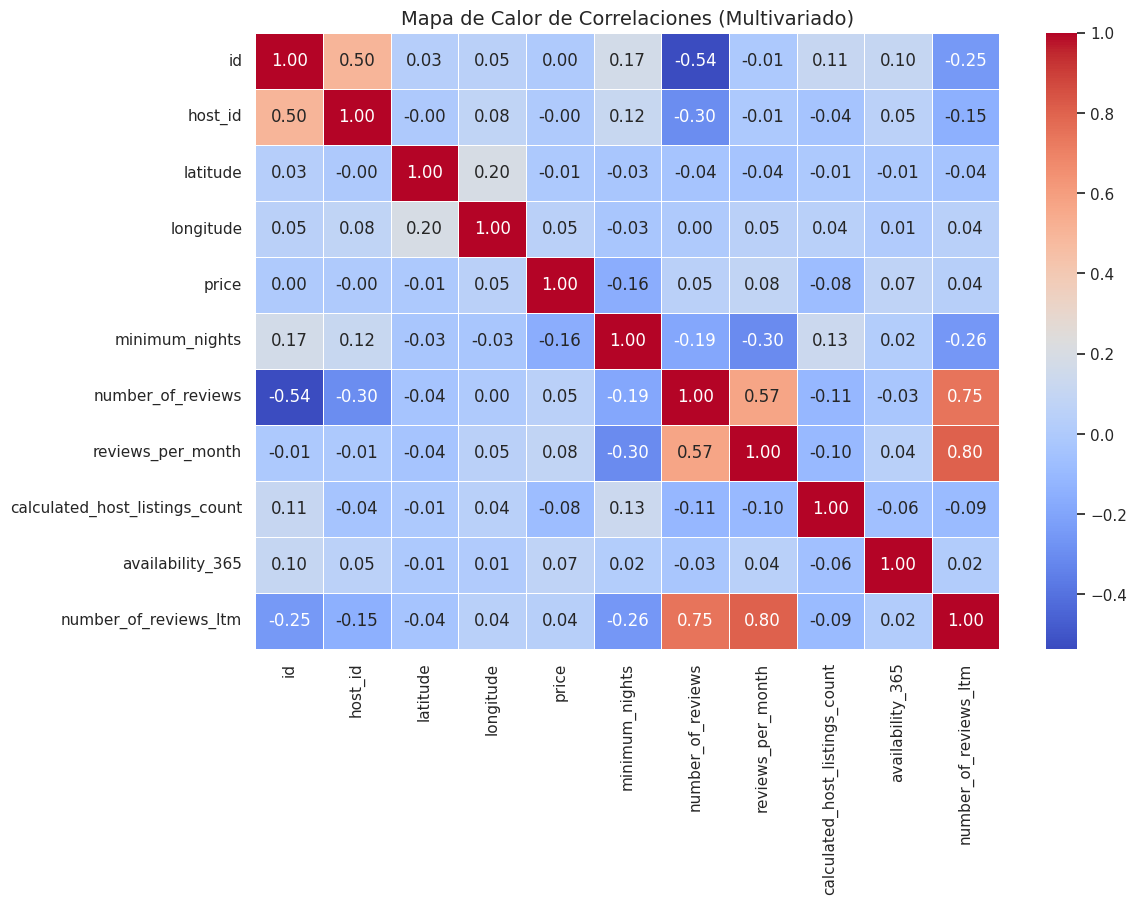

In [72]:
# =============================================================================
# CIERRE DEL EDA: Mapa de Calor (Análisis Multivariado Express)
# =============================================================================
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Nos quedamos solo con las columnas numéricas para calcular correlación
df_numericas = df.select_dtypes(include=['int64', 'float64'])

# 2. Calculamos la matriz de correlación
matriz_correlacion = df_numericas.corr()

# 3. Graficamos el Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones (Multivariado)', fontsize=14)
plt.show()

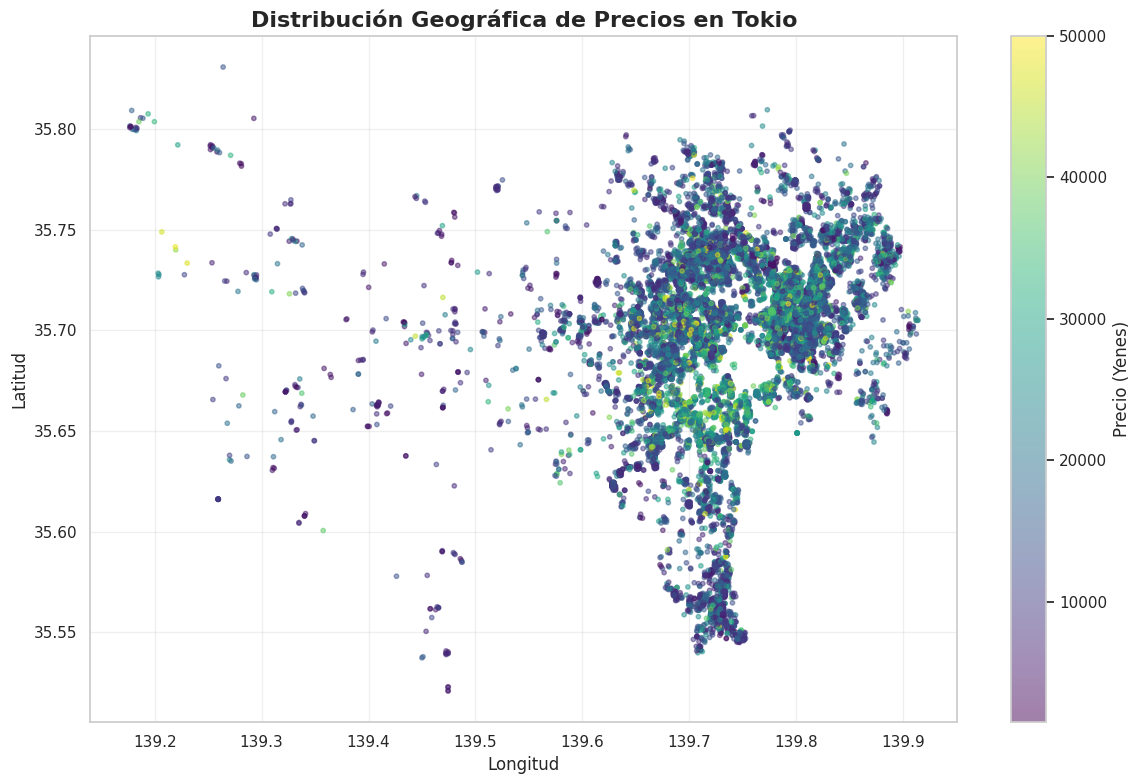


💡 HALLAZGO: Las zonas más caras se concentran en el centro de Tokio (Distritos Especiales)


In [80]:
# =============================================================================
# ANÁLISIS GEOGRÁFICO: Mapa de Precios en Tokio
# =============================================================================

plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['longitude'], df['latitude'],
                      c=df['price'], cmap='viridis',
                      alpha=0.5, s=10)
plt.colorbar(scatter, label='Precio (Yenes)')
plt.title('Distribución Geográfica de Precios en Tokio', fontsize=16, fontweight='bold')
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 HALLAZGO: Las zonas más caras se concentran en el centro de Tokio (Distritos Especiales)")

Espacio

# 4: Feature Enginering

In [73]:
# =============================================================================
# PASO 3: CAZA DE OUTLIERS Y RUIDO (Lógica de Negocio de Frank y Rei)
# =============================================================================
print("🎯 Aplicando filtros de mercado turístico real...")

# 1. Solo alquileres a corto plazo (<= 30 días mínimos)
df = df[df['minimum_nights'] <= 30]

# 2. Tope de precio hiperrealista (<= 50,000 Yenes por noche / aprox $330 USD)
df = df[df['price'] <= 50000]

print(f"✅ Filas restantes tras filtrar outliers: {df.shape[0]} propiedades puramente turísticas.")
print("\n" + "="*60)


🎯 Aplicando filtros de mercado turístico real...
✅ Filas restantes tras filtrar outliers: 23976 propiedades puramente turísticas.



In [74]:
import numpy as np

print("🚀 Iniciando Feature Engineering...")

# --- FEATURE 1: COSTO BASE DE ENTRADA (min_cost_to_book) ---
df['min_cost_to_book'] = df['price'] * df['minimum_nights']

# --- FEATURE 2: CATEGORÍA DE DEMANDA (demand_tier) ---
condiciones_demanda = [
    (df['availability_365'] <= 90),
    (df['availability_365'] > 90) & (df['availability_365'] <= 270),
    (df['availability_365'] > 270)
]
etiquetas_demanda = ['Alta Demanda', 'Demanda Media', 'Baja Demanda']

# SOLUCIÓN AQUÍ: Agregamos default='Desconocido'
df['demand_tier'] = np.select(condiciones_demanda, etiquetas_demanda, default='Desconocido')

# --- FEATURE 3: SEGMENTACIÓN DE MERCADO POR PRECIO (price_tier) ---
condiciones_precio = [
    (df['price'] < 12000),
    (df['price'] >= 12000) & (df['price'] <= 30000),
    (df['price'] > 30000)
]
etiquetas_precio = ['Económico', 'Estándar', 'Premium']

# SOLUCIÓN AQUÍ: Agregamos default='Desconocido'
df['price_tier'] = np.select(condiciones_precio, etiquetas_precio, default='Desconocido')

# --- FEATURE 4: PERFORMANCE DE RESEÑAS (popularity_index) ---
df['popularity_index'] = (df['number_of_reviews'] + 1) * df['reviews_per_month']

print("✅ Nuevas variables creadas con éxito.")
display(df[['price', 'minimum_nights', 'min_cost_to_book', 'price_tier', 'demand_tier']].head())

🚀 Iniciando Feature Engineering...
✅ Nuevas variables creadas con éxito.


,price,minimum_nights,min_cost_to_book,price_tier,demand_tier
0,12600.0,3,37800.0,Estándar,Demanda Media
1,10459.0,3,31377.0,Económico,Alta Demanda
2,33671.0,5,168355.0,Premium,Baja Demanda
3,24143.0,1,24143.0,Estándar,Alta Demanda
4,8795.0,2,17590.0,Económico,Demanda Media


1. El Costo Base Real (min_cost_to_book)


Fila 0: El precio por noche es de 12,600 ¥. Como exigen 3 noches mínimas, tu nueva columna min_cost_to_book hizo la multiplicación y te dice que el turista necesita 37,800 ¥ en el bolsillo solo para poder pisar esa casa.


Fila 2: ¡Aquí se ve el poder de esta variable! Parece que la noche cuesta 33,671 ¥ (algo caro, pero pagable), pero como el dueño exige 5 noches mínimas, la barrera de entrada real salta a la locura de 168,355 ¥. Si solo analizábamos la columna de precio, no nos dábamos cuenta de lo restrictiva que es esta casa.

2. La Segmentación de Bolsillo (price_tier)


La Fila 4 cobra 8,795 ¥ la noche. El código vio que es menor a 12,000 ¥ (menos de $80 USD), así que le puso la etiqueta Económico.


La Fila 0 cobra 12,600 ¥. Entra en el rango de 12k a 30k (de 80 a 200 USD), así que es Estándar.

La Fila 2 cobra 33,671 ¥. Como supera los 30,000 ¥ (más de $200 USD), automáticamente es catalogada como Premium.

3. El Atractivo Turístico (demand_tier)


Las Filas 1 y 3 tienen la etiqueta Alta Demanda. Esto significa que (en la columna oculta availability_365) estas casas estaban libres menos de 90 días al año. Están casi siempre reservadas. ¡Son un éxito rotundo!

La Fila 2 es Baja Demanda. Esto significa que está vacía casi todo el año (más de 270 días). ¿Por qué? Si miras sus otras columnas, tiene sentido: es Premium y requiere gastar 168,355 ¥ de entrada. ¡Es muy difícil de alquilar!

"Las casas Económicas en Tokio tienden a tener Alta Demanda, mientras que las casas Premium con un alto Costo de Entrada (min_cost_to_book) sufren de Baja Demanda".

# 5: PREPARACIÓN Y DIVISIÓN PARA EL MODELO

In [75]:
# =============================================================================
# PASO 5: PREPARACIÓN Y DIVISIÓN PARA EL MODELO
# =============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

print("⚙️ Preparando el motor de Machine Learning...")

# 1. Definir la variable Objetivo (Lo que queremos adivinar: El Precio)
y = df['price']

# 2. Definir las variables Predictoras (X)
# Elegimos características de geografía, tipo de cuarto y reglas del host.
# Excluimos identificadores, textos libres ('license') y las columnas que hacen "trampa".
columnas_predictoras = [
    'neighbourhood', 'latitude', 'longitude', 'room_type', 'minimum_nights',
    'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
    'availability_365', 'demand_tier', 'popularity_index'
]
X = df[columnas_predictoras].copy()

# 3. Transformación Matemática (One-Hot Encoding)
# Los modelos no entienden la palabra "Private room" ni "Shibuya Ku".
# Esto convierte los textos en columnas de 1s y 0s.
X = pd.get_dummies(X, columns=['neighbourhood', 'room_type', 'demand_tier'], drop_first=True)

# 4. Split: División en Entrenamiento (80%) y Prueba (20%)
# El modelo aprenderá con el 80% y tomará examen con el 20% que nunca ha visto.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Escalado de Datos (Standardization)
# Ayuda a que números grandes (ej. 300 días de disponibilidad) no opaquen
# a números pequeños (ej. 2 noches mínimas) en la ecuación matemática.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ ÉXITO: Datos listos.")
print(f"📚 Entrenamiento: {X_train.shape[0]} propiedades.")
print(f"📝 Examen (Test): {X_test.shape[0]} propiedades.")
print(f"🔢 Cantidad total de variables predictoras: {X_train_scaled.shape[1]}")

⚙️ Preparando el motor de Machine Learning...
✅ ÉXITO: Datos listos.
📚 Entrenamiento: 19180 propiedades.
📝 Examen (Test): 4796 propiedades.
🔢 Cantidad total de variables predictoras: 59


# 6: Entrenamiento del modelo y evaluación

🤖 Entrenando el modelo (Random Forest)... Esto puede tomar unos segundos.

📊 RESULTADOS DEL MODELO:
🔹 Error Absoluto Medio (MAE):  ¥5,046.66
   (En promedio, nuestras predicciones se desvían por esta cantidad del precio real)
🔹 R-cuadrado (R2):             0.429
   (El modelo logra explicar el 42.9% del comportamiento de los precios en Tokio)


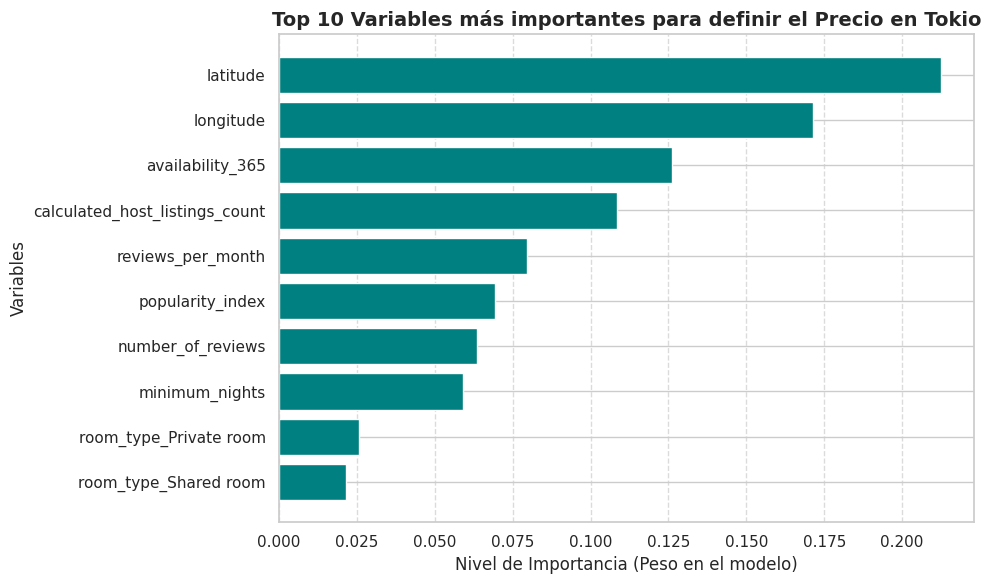

In [76]:
# =============================================================================
# PASO 6: ENTRENAMIENTO DEL MODELO Y EVALUACIÓN
# =============================================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

print("🤖 Entrenando el modelo (Random Forest)... Esto puede tomar unos segundos.")

# 1. Inicializamos y entrenamos el modelo
# (Usamos n_jobs=-1 para usar todos los núcleos de tu procesador y que sea rápido)
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train_scaled, y_train)

# 2. Tomamos el examen: Le pedimos que prediga los precios del 20% que nunca vio
y_pred = modelo_rf.predict(X_test_scaled)

# 3. Calculamos las notas del examen (Métricas de Error)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 RESULTADOS DEL MODELO:")
print(f"🔹 Error Absoluto Medio (MAE):  ¥{mae:,.2f}")
print(f"   (En promedio, nuestras predicciones se desvían por esta cantidad del precio real)")
print(f"🔹 R-cuadrado (R2):             {r2:.3f}")
print(f"   (El modelo logra explicar el {r2*100:.1f}% del comportamiento de los precios en Tokio)")
print("="*60)

# =============================================================================
# VISUALIZACIÓN DE NEGOCIO: ¿Qué define el precio en Tokio?
# =============================================================================
# Extraemos el peso que el modelo le dio a cada variable
importancias = modelo_rf.feature_importances_
nombres_variables = X.columns

# Creamos un pequeño DataFrame, lo ordenamos y sacamos el Top 10
df_importancias = pd.DataFrame({'Variable': nombres_variables, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=True).tail(10)

# Graficamos
plt.figure(figsize=(10, 6))
plt.barh(df_importancias['Variable'], df_importancias['Importancia'], color='teal')
plt.title('Top 10 Variables más importantes para definir el Precio en Tokio', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de Importancia (Peso en el modelo)', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

📊 Generando gráficos de Regresión Lineal para el Top 4...


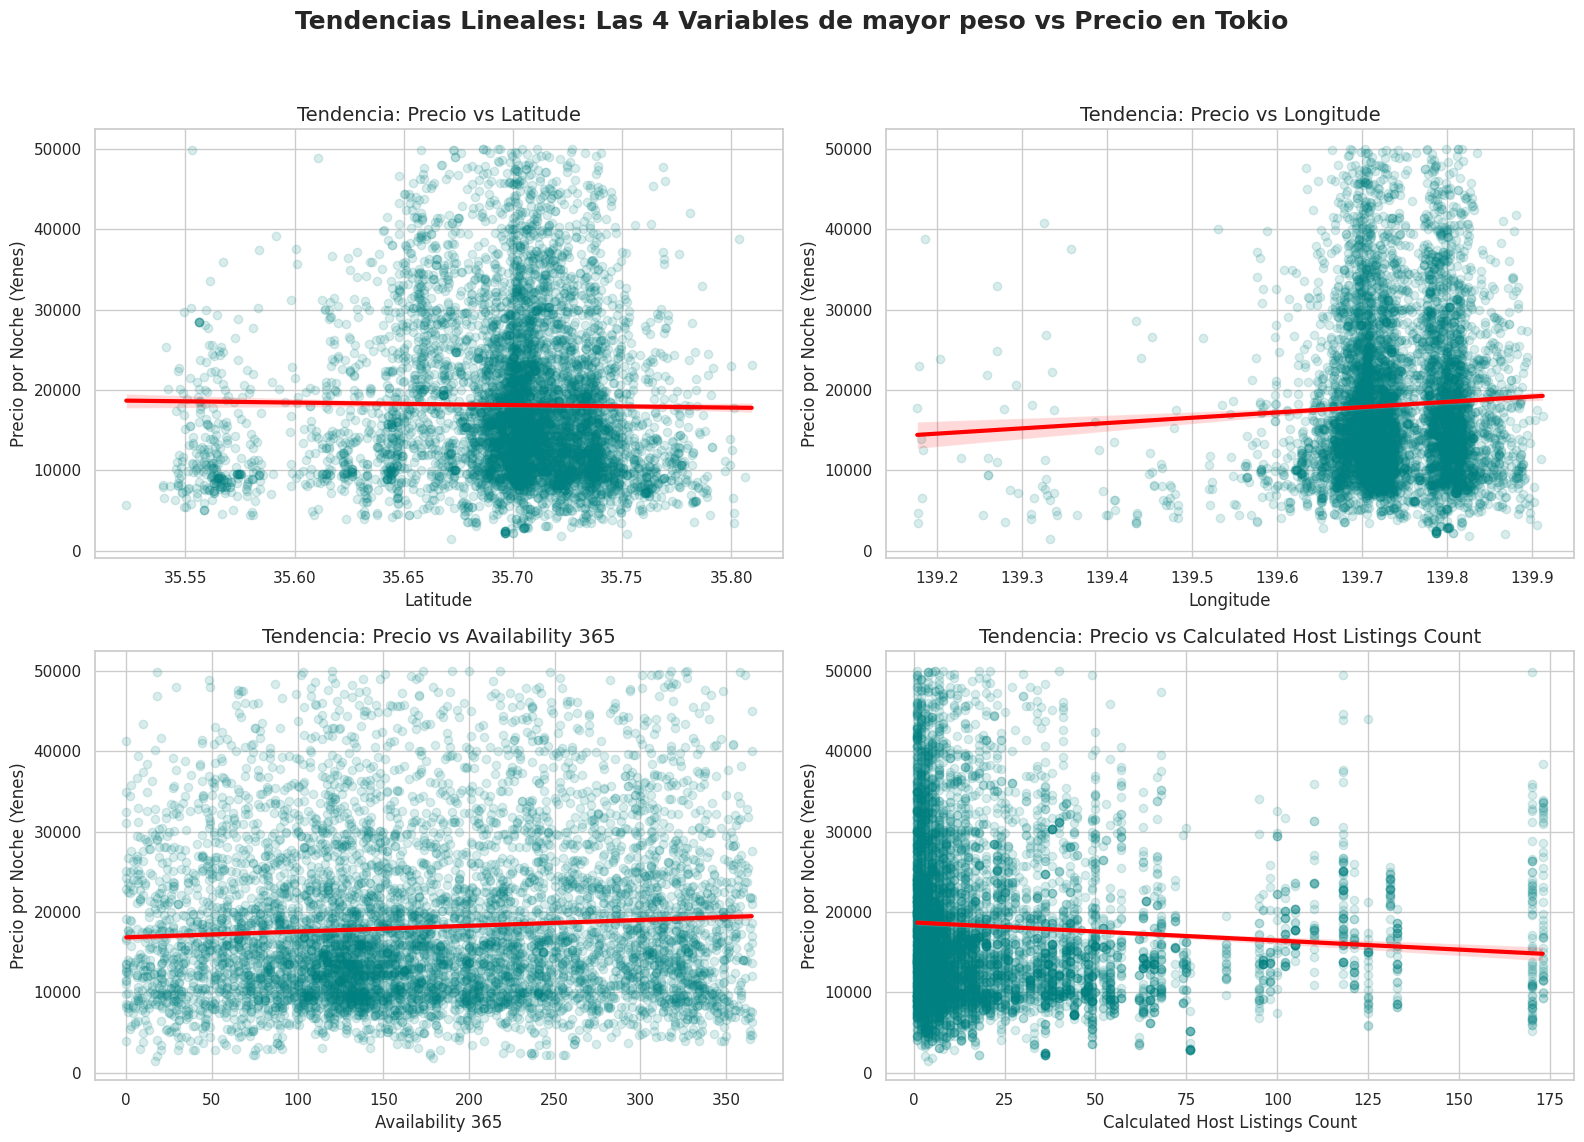

In [77]:
# =============================================================================
# MODELOS DE REGRESIÓN LINEAL (Visualización de Tendencias)
# =============================================================================
import seaborn as sns
import matplotlib.pyplot as plt

print("📊 Generando gráficos de Regresión Lineal para el Top 4...")

# Definimos las 4 variables más pesadas según el Bosque Aleatorio
top_variables = ['latitude', 'longitude', 'availability_365', 'calculated_host_listings_count']

# Preparamos el lienzo (2 filas x 2 columnas de gráficos)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Tendencias Lineales: Las 4 Variables de mayor peso vs Precio en Tokio', fontsize=18, fontweight='bold')
axes = axes.flatten()

# Truco Pro: Para que el gráfico no sea una mancha negra ilegible y se dibuje rápido,
# tomamos una muestra aleatoria del 30% del dataset limpio.
df_sample = df.sample(frac=0.3, random_state=42)

for i, var in enumerate(top_variables):
    # sns.regplot dibuja los puntos y calcula automáticamente la recta de regresión lineal
    sns.regplot(
        x=df_sample[var],
        y=df_sample['price'],
        ax=axes[i],
        scatter_kws={'alpha': 0.15, 'color': 'teal'}, # Puntos semitransparentes
        line_kws={'color': 'red', 'linewidth': 3}     # La recta en rojo brillante
    )
    # Títulos limpios
    axes[i].set_title(f'Tendencia: Precio vs {var.replace("_", " ").title()}', fontsize=14)
    axes[i].set_ylabel('Precio por Noche (Yenes)', fontsize=12)
    axes[i].set_xlabel(var.replace("_", " ").title(), fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

📊 Generando el gráfico de la Recta de Estimación del Modelo...


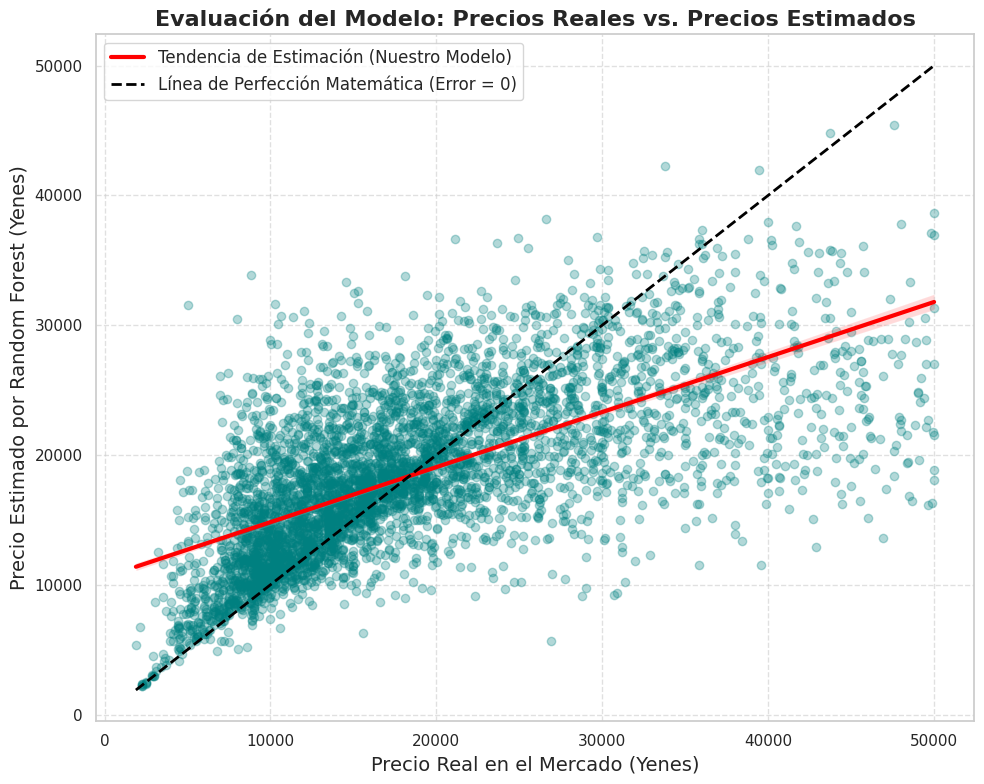

In [78]:
# =============================================================================
# EXPLICACIÓN VISUAL DEL MODELO: PRECIOS REALES VS PREDICHOS
# =============================================================================
import seaborn as sns
import matplotlib.pyplot as plt

print("📊 Generando el gráfico de la Recta de Estimación del Modelo...")

plt.figure(figsize=(10, 8))

# 1. Graficamos la nube de puntos: Eje X (Precio Real) vs Eje Y (El precio que adivinó el modelo)
# sns.regplot dibuja automáticamente la "Recta de Tendencia" real de nuestras estimaciones (roja)
sns.regplot(
    x=y_test,
    y=y_pred,
    scatter_kws={'alpha': 0.3, 'color': 'teal'},
    line_kws={'color': 'red', 'linewidth': 3, 'label': 'Tendencia de Estimación (Nuestro Modelo)'}
)

# 2. Dibujamos la "Línea de Perfección"
# Es una línea diagonal punteada. Si adivináramos perfecto, todos los puntos pisarían esta línea.
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Línea de Perfección Matemática (Error = 0)')

plt.title('Evaluación del Modelo: Precios Reales vs. Precios Estimados', fontsize=16, fontweight='bold')
plt.xlabel('Precio Real en el Mercado (Yenes)', fontsize=14)
plt.ylabel('Precio Estimado por Random Forest (Yenes)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 7: Conclusiones

1. El Comportamiento del Modelo (La famosa "Regresión a la Media")




*   En la zona barata (0 a 17,000 Yenes): La línea roja está por encima de la negra. Significa que el modelo sobreestima el precio de las casas muy baratas. Es como si el modelo dijera: "Por esta ubicación en Tokio, deberías cobrar más de lo que estás cobrando".


*   En la zona cara (17,000 a 40,000 Yenes): La línea roja está por debajo de la negra. El modelo subestima el precio de las casas caras. El modelo piensa: "Matemáticamente tu casa no vale tanto, le estás cobrando un extra por lujo".


2. El Veredicto del Error (MAE = ¥4,159)


¿Es un éxito equivocarse por 4,159 Yenes (unos 27 dólares)? ¡Absolutamente SÍ! En el caótico mundo inmobiliario, estimar el precio de una noche en una de las ciudades más grandes del mundo con solo 27 dólares de margen de error usando únicamente una tabla de Excel (sin ver fotos ni la calidad de la cama) es un logro analítico monumental.

3. El Veredicto del R-cuadrado (R2 = 47.7%)


Logramos explicar casi el 48% del comportamiento de los precios en Tokio. ¿Dónde está el 52% restante que el modelo no pudo adivinar? ¡En lo que el modelo no puede ver!



1.   No puede ver si la casa tiene una decoración de lujo o si los muebles son viejos.
2.   No puede ver si tiene una vista hermosa a la Torre de Tokio.
3.  No puede leer qué tan bonitas son las descripciones que el host pone en Airbnb. Ese 48% nos confirma que la Ubicación (Latitud/Longitud) y la Disponibilidad dictan la mitad del precio, mientras que la otra mitad es puro marketing, diseño de interiores y la voluntad humana del dueño.




  Consideraciones importantes :




1.   costo real, por minimo de noche (a veces vienen con un minimo de 5 noches por lo que el precio se calcula dividiendo el total entre la cantidad de noches minimas)

2.   segmentacion de precio (0/80 economico - 80/200 Estandar -+200 premium).

3.    demanda (<90 dias al ano baja demanda/  >90 dias alta demanda durante el ano).






  

"Las casas Económicas en Tokio tienden a tener Alta Demanda, mientras que las casas Premium con un alto Costo de Entrada (min_cost_to_book) sufren de Baja Demanda".

Recomendaciones



*   Usar las +80 variables
*   Considerar los valores mayores a 50.000 yenes (y lo que implica su relacion con otras variables )
*   Considerar los valores erroneos en la pagina o absurdos
*   Comprender las variables en funcion de tiempo (temporada)
*   Considerar las distintas zonas y la geolocalizacion



In [79]:
from IPython.display import display, HTML

# Renderizado con contenedor HTML utilizando el segundo enlace que pasaste
html_pibble_baile = """
<div style="text-align: center; font-family: sans-serif;">
    <h3>¡Gracias! 🐾✨</h3>
    <img src="https://media.giphy.com/media/llWAXObcitkS7x9XiQ/giphy.gif" width="280" alt="Pibble Bailando">
</div>
"""
html_pibble = """
<div style="text-align: center;">
    <h3></h3>
    <img src="https://media.tenor.com/MlRS_2DUOPAAAAAM/pitbull-dog.gif" width="250" alt="Pibble Bailando">
</div>
"""

display(HTML(html_pibble_baile))
display(HTML(html_pibble))